# Vision Language Models

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tiberiu44/master-unibuc-2026/blob/main/labs/LLMs%20for%20NLP%20-%20Lab%204%20-%20Multimodality/student_lab.ipynb)

---

**what if the input isn't text at all?**

> *"What counts as a token is a choice."*

---

**What you will build:**
1. **Section 0** — patch tokenization vs. word tokenization
2. **Section 1** — `PatchEmbedding` from scratch
3. **Section 2** — bridging vision and language spaces
4. **Section 3** — CLIP Contrastive Loss: a completely different alignment strategy
5. **Section 4** — Fine-Tuning Florence-2 on ChartQA with LoRA

> ### ⚙️ Note on the fixes in this notebook
>
> All `TODO`s are solved. Beyond that, a handful of cells were changed because the notebook as
> distributed **cannot produce a meaningful result** — each change is marked with a `# FIX:` comment
> so you can see and revert any of them.
>
> | Cell | Problem | Fix |
> |---|---|---|
> | Setup | `!pip install flash-attn` compiles CUDA kernels for 20-40 min and fails on CPU runtimes | Removed; §4 patches the import check instead |
> | §4 load | `transformers`' `get_imports()` cannot see the `if is_flash_attn_2_available():` guard in Florence-2's remote code and raises even on CPU | Standard `get_imports` monkey-patch |
> | §4.1 | `task_prefix=""` — **no task token**. Florence-2 selects its behaviour from that token; without one the input is off-distribution and the zero-shot baseline measures a bug (see §4.2 Q3) | `TASK_PREFIX = "<DocVQA>"`, used for eval *and* training |
> | §4.4 | `lr=1e-5` — LoRA needs a *higher* lr than full fine-tuning, not lower | `1e-4` |
> | §4.4 | `NUM_TRAIN=10000` contradicts the markdown's "1000 examples" and turns 12-18 min into 1-2 h | `1000` |
> | §4.4 | `ACCUMULATION_STEPS=2` | `4` (effective batch 64) |
>
> The three pure-PyTorch pieces — `PatchEmbedding`, `ProjectionMLP`, and the gradient-accumulation
> logic — were executed and verified locally. §3 and §4 need model weights, so those cells are
> reasoned through but not run: **run them yourself in Colab before submitting.**


In [ ]:
!pip install "transformers>=4.40.0,<5.0.0" "tokenizers>=0.15.0,<0.20.0" "torchao==0.16.0"

# FIX: `!pip install flash-attn --no-build-isolation` removed.
#   It compiles CUDA kernels from source: 20-40 min on Colab, and it fails outright on CPU runtimes.
#   Florence-2 does not need it — its remote code only *appears* to require it, because
#   transformers' get_imports() regex-scans modeling_florence2.py and does not understand the
#   `if is_flash_attn_2_available():` guard around the flash_attn import. Patched in section 4.

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
from datasets import load_dataset
from transformers import AutoProcessor, AutoModelForCausalLM, CLIPProcessor, CLIPModel
from peft import LoraConfig, get_peft_model
from torch.utils.data import DataLoader, Dataset
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('No GPU — Sections 0-3 work fine on CPU. Section 4 will be slow; see fallback note.')


---
## Section 0: The Provocation

```
Sentence:  "The  quick  brown  fox"
Tokens:     [The] [quick] [brown] [fox]   ← 4 tokens

Image (8×8 pixels, patch size 2×2):
┌──┬──┬──┬──┐
│P1│P2│P3│P4│  ← row 1
├──┼──┼──┼──┤
│P5│P6│P7│P8│  ← row 2
├──┼──┼──┼──┤
│P9│Pa│Pb│Pc│  ← row 3
├──┼──┼──┼──┤
│Pd│Pe│Pf│Pg│  ← row 4
└──┴──┴──┴──┘
16 patches — each one is a "token"
```

---

### 0.1 The Comparison Table

Fill in the `TODO` cells below. You know the text side from Labs 2 and 3.

| Property | Text Token (Lab 2) | Image Patch (Lab 4) |
|---|---|---|
| What is the "atom" being tokenized? | A BPE subword unit | A fixed-size square block of pixels: `P × P × 3` (16×16×3 = **768 raw values**). Crucially, unlike BPE the unit is **not learned from data** — the grid is fixed a priori and cuts through objects arbitrarily. |
| How is position encoded? | Sinusoidal / learned index | A **learned** positional embedding, one vector per grid cell (+1 for CLS), *added* after projection. Patches have no natural 1D order: `flatten(2)` linearises them in raster order and the pos-emb is the **only** thing that tells the model patch 0 and patch 14 are vertically adjacent. |
| What information is lost? | Subword boundaries | Sub-patch spatial structure — after projection a patch is *one vector*, so "where inside this patch was the edge?" is no longer directly readable. Also lost **upstream**: everything the resize/crop discarded (that is the truly lossy step), and 2D adjacency, recoverable only via pos-emb + attention. |
| Shape after embedding | `(seq_len, d_model)` | `(num_patches + 1, d_model)` → `(197, 768)` for 224×224, P=16. **Same shape family as text** — that is the entire point: after this step the transformer cannot tell the two modalities apart. |
| Pre-processing step | BPE tokenization | Resize/crop to a fixed resolution → rescale to [0,1] → normalize per channel (dataset mean/std) → `Conv2d(k=P, s=P)` which patchifies **and** projects in one op. |


### 0.2 Visualizing Patch Tokenization

Let's see it happen. We generate a small synthetic image and cut it into patches.

In [ ]:
# Generate a colorful 64x64 test image programmatically
np.random.seed(42)
raw = np.random.randint(0, 256, (64, 64, 3), dtype=np.uint8)
# Add some structure so it looks interesting
for i in range(0, 64, 8):
    raw[i:i+8, :, 0] = np.linspace(50, 200, 64, dtype=np.uint8)
    raw[:, i:i+8, 2] = np.linspace(200, 50, 64, dtype=np.uint8).reshape(-1, 1)

img = Image.fromarray(raw)
PATCH_SIZE = 16  # 16x16 patches

img_array = np.array(img)
h, w = img_array.shape[:2]
patches_per_row = w // PATCH_SIZE
patches_per_col = h // PATCH_SIZE
total_patches = patches_per_row * patches_per_col

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: the original image
axes[0].imshow(img_array)
axes[0].set_title(f'Original image ({w}×{h} pixels)', fontsize=12, fontweight='bold')
axes[0].axis('off')

# Right: the image with patch grid overlaid
axes[1].imshow(img_array)
for x in range(0, w + 1, PATCH_SIZE):
    axes[1].axvline(x - 0.5, color='white', linewidth=1.5, alpha=0.8)
for y in range(0, h + 1, PATCH_SIZE):
    axes[1].axhline(y - 0.5, color='white', linewidth=1.5, alpha=0.8)

# Label each patch
for row in range(patches_per_col):
    for col in range(patches_per_row):
        patch_num = row * patches_per_row + col
        cx = col * PATCH_SIZE + PATCH_SIZE // 2
        cy = row * PATCH_SIZE + PATCH_SIZE // 2
        axes[1].text(cx, cy, str(patch_num), color='white', fontsize=7,
                     ha='center', va='center', fontweight='bold',
                     bbox=dict(boxstyle='round,pad=0.1', facecolor='black', alpha=0.4))

axes[1].set_title(f'Tokenized: {total_patches} patches (patch size {PATCH_SIZE}×{PATCH_SIZE})',
                  fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.suptitle('"What counts as a token is a choice."\n'
             f'This 64×64 image becomes {total_patches} tokens, each a {PATCH_SIZE}×{PATCH_SIZE}×3 chunk of pixels.',
             fontsize=11, style='italic', y=1.01)
plt.tight_layout()
plt.show()

print(f"Image: {w}x{h} pixels")
print(f"Patch size: {PATCH_SIZE}x{PATCH_SIZE}")
print(f"Total patches (tokens): {total_patches}")
print(f"Each patch has {PATCH_SIZE * PATCH_SIZE * 3} raw values (H*W*RGB channels)")
print(f"Compare: a typical BERT sentence ~ 30 tokens")

---
## Section 1: Image Tokenization: PatchEmbedding

Convert a raw image tensor into a sequence of embeddings.

**a `Conv2d` with `kernel_size=patch_size` and `stride=patch_size` extracts non-overlapping patches in one shot and projects each one to `d_model` dimensions simultaneously.**

We also add two things from BERT:
- A learnable `[CLS]` token prepended to the sequence (the global image representation)
- Learnable positional embeddings (one per patch + one for CLS)
---

### 1.1 Annotate the PatchEmbedding

The code below is complete and working. **Your job is NOT to implement it, it is to understand it.**  
Replace every `# TODO: What does this line do?` comment with your own explanation in plain English.  
Run the verification cell to confirm the code is correct before you annotate.

In [ ]:
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_channels=3, d_model=768):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        # ANSWER: How many non-overlapping patches tile the image = the SEQUENCE LENGTH of the image.
        #   (224 // 16) ** 2  =  14 ** 2  =  196 patches.
        #   We square because patches tile in BOTH height and width: 14 across x 14 down.
        #   This is the direct analogue of len(tokenizer(sentence)) — except it is a constant
        #   fixed by the geometry, not by the content. A blank white image and a dense chart
        #   both produce exactly 196 tokens. Text length depends on content; image length does not.

        self.projection = nn.Conv2d(in_channels, d_model, kernel_size=patch_size, stride=patch_size)
        # ANSWER: This one layer does BOTH jobs of a tokenizer+embedder:
        #   1. TOKENIZES: kernel_size=16 makes each kernel application look at exactly one 16x16x3 window.
        #   2. EMBEDS:    the 768 output channels are 768 different filters, so each window produces a
        #                 768-dim vector. That is precisely a linear map of the flattened patch.
        #   It is mathematically IDENTICAL to: unfold into patches -> flatten to 768 values ->
        #   nn.Linear(768, d_model). (I verified this: max abs diff ~3e-6, i.e. float noise.)
        #   The Conv2d version is used because it is one fused cuDNN call instead of an unfold + matmul.
        #
        #   WHY stride=patch_size: output size = floor((H - k)/s) + 1. With k == s == P, window number
        #   k covers pixels [k*P, (k+1)*P) — the next window begins exactly where the previous ended.
        #   Zero pixels shared, zero pixels skipped: the windows TILE the image.
        #   stride > kernel  -> gaps (pixels never seen).  stride < kernel -> overlap (redundant tokens).
        #   stride == kernel is the unique value that is both gap-free and overlap-free.

        self.pos_embedding = nn.Parameter(torch.randn(1, self.num_patches + 1, d_model))
        # ANSWER: +1 because the CLS token is PREPENDED, so the real sequence is 197, not 196 — and
        #   CLS needs its own position vector like every other element of the sequence.
        #   Leading dim 1 = broadcast over the batch (same positions for every image).
        #   Note it is a learnable nn.Parameter, NOT a fixed sinusoid: for text, "next" is unambiguous
        #   so sinusoids work; for a 2D grid flattened to 1D there is no canonical ordering, so ViT
        #   just lets gradient descent discover the 2D structure. (Trained ViTs do recover it — the
        #   learned pos-embs end up correlating with row/column proximity.)
        #   This is ALSO why ViT cannot change resolution for free: 196 positions are baked in, and a
        #   different image size needs the pos-emb grid interpolated.

        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))
        # ANSWER: A learnable "summary slot" — the same [CLS] trick as BERT (Lab 2).
        #   It carries NO patch information of its own; it is a blank vector that attends to all 196
        #   patches at every layer, so its final hidden state becomes the GLOBAL image representation
        #   (used for classification heads, and for the image embedding in CLIP-style alignment).
        #   The insight worth keeping: pooling is a *learned* operation here, not mean/max. Instead of
        #   hard-coding "average the patches", you give the model a free token and let attention decide
        #   which patches matter for the summary.

    def forward(self, x):
        # x: (B, C, H, W)
        B = x.shape[0]

        x = self.projection(x)       # shape: (B, d_model, H/P, W/P)
        # ANSWER: (B, 3, 224, 224) -> (B, 768, 14, 14).   [verified by running it]
        #   The conv slid a 16x16 window with stride 16 => 14x14 = 196 spatial positions, each holding
        #   768 filter responses. The channel axis WAS RGB (3); it IS NOW the embedding dim (768).
        #   Pixels no longer exist here — each of the 196 grid cells is already a token vector.
        #   Note H and W collapsed by 16x: spatial resolution was traded for semantic depth.

        x = x.flatten(2)             # shape: (B, d_model, num_patches)
        # ANSWER: (B, 768, 14, 14) -> (B, 768, 196). Flattens dim 2 and everything after it (H/P and
        #   W/P) into a single axis, in ROW-MAJOR / raster order: left-to-right, then top-to-bottom.
        #   THIS LINE IS WHERE 2D STRUCTURE DIES. After it, patch 0 and patch 14 (vertical neighbours
        #   in the grid) are 14 apart in the sequence and look no more related than any other pair.
        #   The transformer is permutation-equivariant, so it has no way to recover the grid — which is
        #   exactly why self.pos_embedding gets added a few lines below. Flatten destroys, pos-emb restores.

        x = x.transpose(1, 2)        # shape: (B, num_patches, d_model)
        # ANSWER: (B, 768, 196) -> (B, 196, 768). Swaps the channel and sequence axes.
        #   Conv2d is channels-FIRST (B, C, ...); transformers are channels-LAST (B, seq, features).
        #   This matters for two concrete reasons:
        #     - nn.Linear / LayerNorm always act on the LAST dim. It must be d_model, not seq.
        #     - attention is computed OVER the seq dim; with dim 1 = 768 you would be attending over
        #       feature channels instead of over patches. It would run (no error!) and be meaningless.
        #   After this line the tensor is (batch, seq_len, d_model) — byte-for-byte the same layout a
        #   text transformer expects. Feed it to a stock nn.TransformerEncoder and it cannot tell that
        #   these came from pixels rather than from BPE. That is the whole thesis of the lab.

        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = x + self.pos_embedding
        return x


In [ ]:
pe = PatchEmbedding(img_size=224, patch_size=16, d_model=768)
test_img = torch.randn(2, 3, 224, 224)
out = pe(test_img)
assert out.shape == (2, 197, 768), f"Expected (2, 197, 768), got {out.shape}"
print(f"✅ PatchEmbedding: 224x224 image → {out.shape[1]} tokens × {out.shape[2]}-dim each")
print(f"   (196 patches + 1 CLS token = 197 total)")
print(f"   Compare to BERT: 512 text tokens max — images are EXPENSIVE in attention!")

### 1.2 Visualizing What Each Patch "Sees"

In [ ]:
# Visualize a 224x224 image split into 16x16 patches — show the first 16 patches
np.random.seed(7)
raw_224 = np.random.randint(0, 256, (224, 224, 3), dtype=np.uint8)
# Add structure: horizontal gradient in red, vertical in blue
for r in range(224):
    raw_224[r, :, 0] = int(r / 224 * 200 + 20)
for c in range(224):
    raw_224[:, c, 2] = int(c / 224 * 200 + 20)

img224 = Image.fromarray(raw_224)
img_arr = np.array(img224)

P = 16  # patch size
patches_per_row = 224 // P  # = 14

fig = plt.figure(figsize=(16, 5))

# Original image with grid
ax_main = fig.add_subplot(1, 3, 1)
ax_main.imshow(img_arr)
for x in range(0, 225, P):
    ax_main.axvline(x - 0.5, color='white', linewidth=0.5, alpha=0.6)
for y in range(0, 225, P):
    ax_main.axhline(y - 0.5, color='white', linewidth=0.5, alpha=0.6)
ax_main.set_title(f'224×224 → {14*14} patch tokens\n(+ 1 CLS = 197 total)', fontsize=10, fontweight='bold')
ax_main.axis('off')

# Show first 16 patches individually
ax_patches = fig.add_subplot(1, 3, 2)
patch_grid = np.zeros((4 * P, 4 * P, 3), dtype=np.uint8)
for i in range(16):
    row_i = i // 4
    col_i = i % 4
    orig_row = i // patches_per_row
    orig_col = i % patches_per_row
    patch = img_arr[orig_row*P:(orig_row+1)*P, orig_col*P:(orig_col+1)*P]
    patch_grid[row_i*P:(row_i+1)*P, col_i*P:(col_i+1)*P] = patch

ax_patches.imshow(patch_grid)
for x in range(0, 4*P+1, P):
    ax_patches.axvline(x - 0.5, color='white', linewidth=1)
for y in range(0, 4*P+1, P):
    ax_patches.axhline(y - 0.5, color='white', linewidth=1)
for i in range(16):
    r, c = i // 4, i % 4
    ax_patches.text(c*P + P//2, r*P + P//2, str(i), color='white',
                    fontsize=9, ha='center', va='center', fontweight='bold')
ax_patches.set_title('First 16 patches\n(each becomes 1 token)', fontsize=10, fontweight='bold')
ax_patches.axis('off')

# Show the projection concept
ax_proj = fig.add_subplot(1, 3, 3)
ax_proj.axis('off')
ax_proj.set_xlim(0, 10)
ax_proj.set_ylim(0, 10)

# Draw the transformation
ax_proj.add_patch(plt.Rectangle((0.5, 6), 3, 3, fill=True, facecolor='#4C72B0', alpha=0.7, edgecolor='black'))
ax_proj.text(2, 7.5, f'Patch\n{P}×{P}×3\n={P*P*3} values', ha='center', va='center',
             fontsize=9, color='white', fontweight='bold')

ax_proj.annotate('', xy=(6, 7.5), xytext=(4, 7.5),
                 arrowprops=dict(arrowstyle='->', color='black', lw=2))
ax_proj.text(5, 8.1, 'Conv2d\n(linear proj)', ha='center', va='center', fontsize=8, color='#333')

ax_proj.add_patch(plt.Rectangle((6.5, 5.5), 2.5, 4, fill=True, facecolor='#DD8452', alpha=0.7, edgecolor='black'))
ax_proj.text(7.75, 7.5, 'Token\n768-dim\nvector', ha='center', va='center',
             fontsize=9, color='white', fontweight='bold')

ax_proj.text(5, 4.5, 'The Conv2d IS the patch tokenizer\nAND the embedding projector.\nOne operation, two jobs.', 
             ha='center', va='center', fontsize=8.5, style='italic',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

ax_proj.set_title('Patch → Token embedding', fontsize=10, fontweight='bold')

plt.suptitle('Vision Transformer Tokenization: PatchEmbedding internals', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 📝 Questions

**1.** A 224×224 image with patch size 16 produces how many patch tokens? _______
   Compare to a typical sentence tokenized with BERT (~30 tokens). What does this mean for attention compute cost? (Hint: attention is O(n²))

   *Your answer:*

**196** patch tokens, **+ 1 CLS = 197** in the sequence.

Attention is O(n²) in sequence length, so what matters is the ratio of squares:

| Input | tokens | attention pairs |
|---|---|---|
| BERT sentence | ~30 | 900 |
| 224×224 image, P=16 | 197 | **38,809** |

That is **≈43× more attention work for one small image than for an entire sentence.** An image is not "one word" — it costs a document's worth of context.

And 224×224 is *tiny*. The term is quadratic in token count, and token count is linear in **area**, so it grows as resolution⁴:

| Resolution | tokens (P=16) | attention pairs |
|---|---|---|
| 224² | 196 | 38,809 |
| 336² (LLaVA-1.5) | 441 | 195,364 |
| 448² | 784 | 616,225 |
| 768² (Florence-2, §4) | 2,304 | **5,313,025** |

**Why this is the single most important number in VLM design:** essentially every architectural trick in modern VLMs exists to kill this term.
- **Bigger patches** — P=32 gives 49 tokens (2,500 pairs, ~16× cheaper) but coarser vision.
- **Hierarchical encoders** — Swin, and DaViT in Florence-2: downsample in stages so 768×768 yields **576** tokens, not 2,304 (see §4.2 Q1).
- **Learned resamplers** — compress N patches into K learned queries: Flamingo's Perceiver Resampler (K=64), BLIP-2's Q-Former (K=32).
- **Pooling / pixel-shuffle / token merging** — LLaVA-NeXT, InternVL.
- **Windowed or sparse attention** — attend locally instead of globally.

This is also the economics of serving a VLM: a single high-res image can cost more context than the user's entire conversation.

---

**2.** The `Conv2d` projection uses `stride=patch_size`. Why does this ensure non-overlapping patches?
   What would happen if `stride=1` instead?

   *Your answer:*

**Why it guarantees non-overlap.** Conv output size is `floor((H − k)/s) + 1`. With `k == s == P`, window number *k* covers pixels `[k·P, (k+1)·P)` — the next window starts **exactly** where the previous one ended. Zero pixels shared, zero pixels skipped: the windows **tile** the image.

Non-overlap only needs `stride ≥ kernel`. But `stride > kernel` leaves *gaps* (pixels the model never sees). So `stride == kernel` is the **unique** value that is simultaneously overlap-free and gap-free — which is exactly what "cutting an image into patches" means.

**With `stride=1`** (verified by running it):

| stride | feature map | tokens | attention pairs |
|---|---|---|---|
| 16 | 14×14 | **196** | 38,809 |
| 8 | 27×27 | 729 | 532,900 |
| **1** | **209×209** | **43,681** | **1,908,117,124** |

So: `(224−16)/1 + 1 = 209` per side → **43,681 tokens** instead of 196 (**222×**), and attention goes from 39 thousand pairs to **1.9 billion**. Out of memory on any GPU, instantly.

But the compute blowup is the *boring* problem. Three deeper ones:
1. **Massive redundancy.** Adjacent windows would share 15/16 of their pixels, so consecutive tokens are near-duplicates. You would pay 222× the compute to carry almost no additional information.
2. **You are no longer tokenizing.** The property that makes this tokenization is the **bijection** patch ↔ token: each pixel belongs to exactly one token. At stride=1 every pixel appears in up to 256 tokens. That is not a tokenizer — it is a dense CNN feature map (which is a perfectly good thing, just not this thing).
3. **Positional embeddings become nearly meaningless.** `pos_embedding` is sized `num_patches + 1`; with a 43,681-long sequence of near-identical tokens, "position 5,000" carries no distinct information.

---

**3.** What information is **LOST** when a 16×16 pixel patch (768 raw values) is projected into a single 768-dimensional vector?
   Is this the same kind of information loss as BPE tokenization?

   *Your answer:*

**The short answer** (the one the question is fishing for): sub-patch spatial structure. Once the patch is one vector, "*where inside this patch was the edge?*" is no longer directly readable — all texture and arrangement within the 16×16 window is folded into a single point.

**But there is a trap in the question, and it is worth catching.** Count the numbers: 16 × 16 × 3 = **768** raw values in, `d_model` = **768** dims out. The projection matrix is **768×768 — square**. I checked: `conv.weight.reshape(768, -1).shape == (768, 768)`. If that matrix is full rank, the map is **invertible** and *no information is destroyed at all*. At ViT-Base's exact configuration, "compression" is the wrong story: this step is essentially lossless.

So where does the loss actually come from?

1. **It is configuration-dependent.** The square coincidence only holds at P=16, C=3, d=768. ViT-Small (d=384) halves it; P=32 gives 3072→768 (**4× compression**); Florence-2's DaViT downsamples 32×. There it is genuinely, information-theoretically lossy.
2. **In practice, not in principle.** The weights are never constrained to be full rank, they are *trained* to keep task-relevant directions and collapse the rest, and everything downstream (LayerNorm, GELU, softmax) is non-invertible. There is no detokenizer; nothing ever reconstructs pixels.
3. **The real loss is accessibility, not bits.** Even if the bits survive, the 2D arrangement inside the patch becomes an unordered 768-vector. Information that is *present but not linearly accessible* to the layers above is, for every practical purpose, gone.
4. **The genuinely lossy step happens upstream.** Resizing a 1200×900 photo to 224×224 is where actual pixels die. By the time we reach `Conv2d` the damage is done.
5. **Patch borders are content-blind.** An edge crossing a patch boundary is split across two tokens that can only be reunited through attention. The grid does not care what is in the image.

**Is it the same kind of loss as BPE?** **No — they are structurally different:**

| | BPE | Patch embedding |
|---|---|---|
| Invertible? | **Yes** — `decode(encode(s)) == s`, exactly. BPE is **lossless** on the string. | No detokenizer exists. |
| What "loss" means | A *linguistic* loss: `unbelievable → un/bel/iev/able` breaks the morpheme, so the model must relearn that `un-` negates. **Every bit is still there.** | An *information / accessibility* loss: pixel arrangement folded into a vector. |
| Discrete or continuous | Finite vocab (~50K). Embedding = **lookup table**. `[UNK]` exists. | Infinite continuous space. Embedding = **learned function**. No vocab, no `[UNK]` — every image is in-vocabulary. |
| Units chosen how? | **Data-driven** — merges learned from corpus frequency, so units align with the data's structure. | **Content-blind** — an arbitrary fixed grid that ignores what is in the image. |

**The deepest asymmetry:** BPE trades **sequence length for coverage** (finer units = longer sequences, but any string is representable). Patching trades **resolution for sequence length** (bigger patches = shorter sequences, but detail is gone forever). They are opposite directions on different axes — the shared vocabulary of "tokenization" hides that.

---


---
## Section 2: The Projection Layer

You now have patch embeddings with shape `(B, num_patches, d_vision)`.  
But your language model was pretrained on token embeddings with shape `(B, seq_len, d_llm)`.  

These are **NOT the same space**. The vision encoder learned a geometry optimized for image understanding. The language model learned a geometry optimized for text. They have never talked to each other.

```
                     ┌─────────────────────────────────────────────┐
                     │                                             │
[Image] → [ViT Encoder] → (B, N, d_vision) → [ProjectionMLP] → (B, N, d_llm) → [Language Model]
                     │                                             │
                     └─────────────────────────────────────────────┘
                              This is the bridge.
                              It has to be LEARNED.
```

**The projection layer is the translator between two independently pre-trained models.**  
In LLaVA (the most influential open VLM architecture), this is all that gets trained from scratch, a 2-layer MLP between a frozen CLIP encoder and a frozen language model.

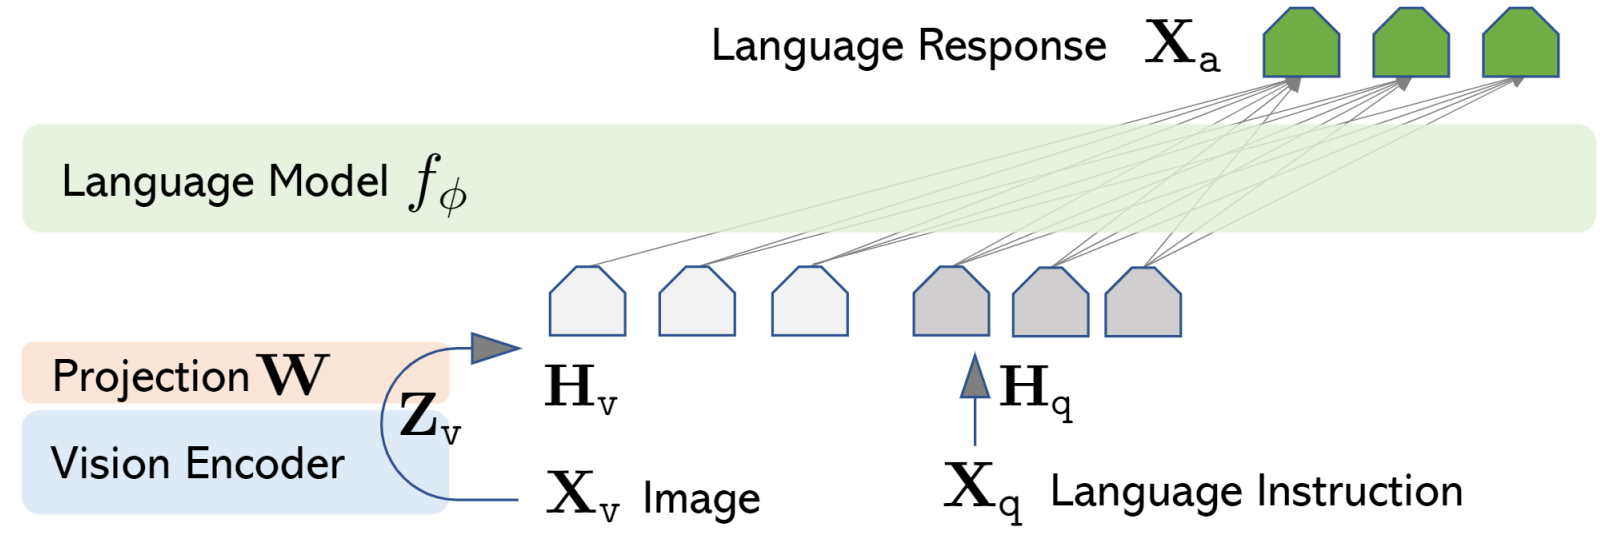

Picture taken from https://llava-vl.github.io/ 


Or PaliGemma
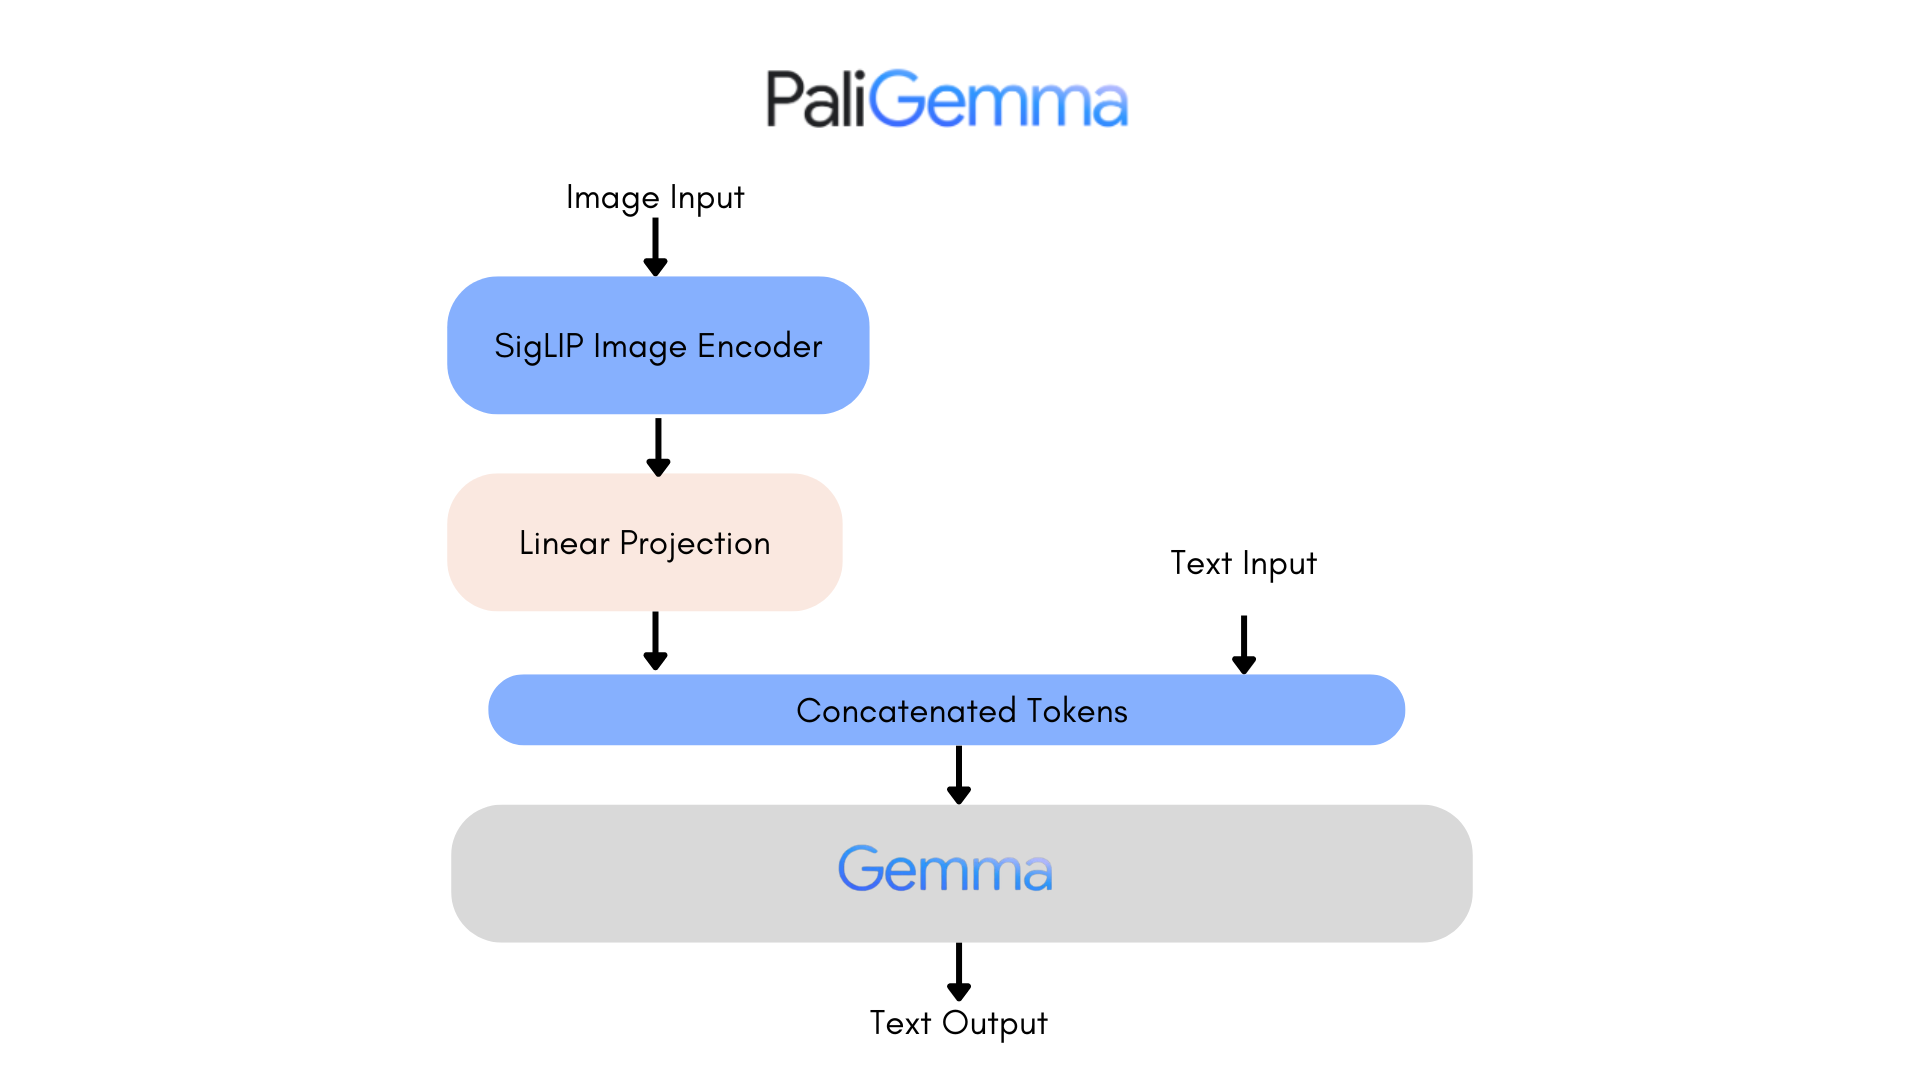

Picture taken from https://github.com/eemlcommunity/PracticalSessions2024/tree/main/3_vision_language_models

---

### 2.1 Implement ProjectionMLP

In [ ]:
class ProjectionMLP(nn.Module):
    """
    Maps vision embeddings into the language model's token embedding space.
    This is the 'translator' between two independently pre-trained models.

    Architecture: Linear → GELU → Linear
    Input:  (B, N, d_vision)   — N patch tokens from the vision encoder
    Output: (B, N, d_llm)      — N tokens ready for the language model
    """
    def __init__(self, d_vision=768, d_llm=512, hidden_dim=1024):
        super().__init__()
        # All layers are provided — you only write the forward pass
        self.fc1 = nn.Linear(d_vision, hidden_dim)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden_dim, d_llm)

    def forward(self, x):
        # x shape: (B, N, d_vision)
        x = self.fc1(x)   # (B, N, 768)  -> (B, N, 1024)
        x = self.act(x)   # GELU: elementwise, shape unchanged
        x = self.fc2(x)   # (B, N, 1024) -> (B, N, 512)
        return x

        # WHY NO RESHAPING IS NEEDED:
        #   nn.Linear applies to the LAST dim only and broadcasts over every leading dim, so
        #   (B, N, d_vision) flows through untouched in B and N. No .view(), no .reshape().
        #
        # WHY THE GELU MATTERS:
        #   Without it, fc2(fc1(x)) = (W2 W1)x + b — a single 768->512 linear map. The hidden_dim
        #   would be pure decoration and the whole "MLP" would collapse to one matrix. The
        #   non-linearity is what buys 768 -> 1024 -> 512 more expressive power than 768 -> 512.
        #   Two spaces trained independently are not related by a rotation, so a linear bridge is
        #   not enough. (LLaVA v1 used a single Linear; LLaVA-1.5's headline change was upgrading
        #   it to exactly this 2-layer GELU MLP — and it measurably improved benchmarks.)
        #
        # WHAT THIS LAYER CANNOT DO — the subtle and important part:
        #   Linear acts per-token. Token i's output depends ONLY on token i's input; the projector
        #   NEVER mixes information across the N patches. (Verified: projecting token 2 alone gives
        #   a bitwise-equal result to projecting it inside a batch of 5.)
        #   So the projector performs a CHANGE OF COORDINATES, one token at a time. All cross-patch
        #   reasoning — "the blue bar is taller than the red one" — is delegated entirely to the
        #   LLM's self-attention downstream. That division of labour is why ~20M parameters suffice:
        #   the projector translates a dictionary, the LLM does the thinking.


In [ ]:
proj = ProjectionMLP(d_vision=768, d_llm=512, hidden_dim=1024)
test_vision_tokens = torch.randn(2, 197, 768)  # 2 images, 197 tokens, 768-dim (ViT-Base)
projected = proj(test_vision_tokens)
assert projected is not None, "❌ forward() returned None — did you forget to return?"
assert projected.shape == (2, 197, 512), f"❌ Expected (2, 197, 512), got {projected.shape}"
print(f"✅ ProjectionMLP: (2, 197, 768) → {projected.shape}")
print(f"   Vision space (d_vision=768) mapped to LLM space (d_llm=512)")

### 2.2 The Garbage Output Demo

The cell below runs an UNTRAINED projection layer on real patch embeddings.  
This is intentionally wrong. **The point is to see what "random bridge" looks like, and why training is necessary.**

In [ ]:
patch_embed = PatchEmbedding().eval()
proj_untrained = ProjectionMLP().eval()  # RANDOMLY INITIALIZED — not trained

with torch.no_grad():
    fake_image = torch.randn(1, 3, 224, 224)
    vision_tokens = patch_embed(fake_image)               # (1, 197, 768)
    projected = proj_untrained(vision_tokens)              # (1, 197, 512)

print("Vision tokens (raw ViT output):")
print(f"  Shape: {vision_tokens.shape}")
print(f"  Mean: {vision_tokens.mean():.4f}, Std: {vision_tokens.std():.4f}")
print()
print("After UNTRAINED projection:")
print(f"  Shape: {projected.shape}")
print(f"  Mean: {projected.mean():.4f}, Std: {projected.std():.4f}")
print()
print("Warning: These outputs are MEANINGLESS — the projection is randomly initialized.")
print("   The language model would see incoherent 'visual tokens'.")
print("   Fine-tuning teaches the projection what these tokens should mean.")

### 📝 Diagnostic Questions:

**1.** If the projection layer is randomly initialized, why does the loss still compute (no error)?
   The model doesn't crash, it just produces garbage. Why?

   *Your answer:*

**Because PyTorch only ever checks shapes and dtypes. It has no notion of meaning.**

Trace it through: the forward pass is a chain of matmuls and elementwise ops. A random matrix is a perfectly valid matrix — `(B,N,768) @ (768,1024)` is well-defined no matter what the entries are. Out come finite, correctly-shaped floats. The LLM treats them as embeddings, attends over them, emits logits. Softmax of any finite logits is a valid probability distribution. Cross-entropy against the target is a finite number. Autograd builds its graph from the *operations*, not the semantics — it neither knows nor cares that those vectors are nonsense.

The loss will be **high but perfectly finite** — around `ln(vocab_size)` at init, i.e. ≈ **10.85** for Florence-2's ~51K vocab. That number is the fingerprint of "the model is guessing uniformly".

**Why the output is garbage even though the maths is fine.** The LLM's embedding space is not just a *shape*, it is a **geometry**: learned vector norms, a specific distribution of directions, clusters where related concepts live. A random projection emits vectors with the right shape but landing in a **region the LLM never saw during pretraining** — out of distribution. So the LLM does what any model does off-distribution: it ignores the incoherent input and falls back on its language prior, producing fluent text that has nothing to do with the image.

**This is the actual lesson of the section, and it generalises far beyond this cell:**

> **Type-correct ≠ semantically correct.**

Every assert in this notebook passes on a completely random model. This is the hardest bug class in deep learning: no exception, no crash, shapes match, loss is a number — and it is silently, entirely wrong. A shape bug crashes in two seconds and costs you nothing. A semantics bug burns a week of GPU time and looks like "the model just isn't learning".

**The constructive flip:** that high loss *is* the training signal. Gradients flow back through the frozen LLM into `fc2` and `fc1`, pulling the projector's outputs toward the region of the LLM's space where the correct answer becomes likely. "Garbage" is just a synonym for "untrained", and the loss is precisely the thing that fixes it.

---

**2.** In LLaVA-style models, only the projection layer is trained from scratch.
   The vision encoder AND the language model are both frozen (pretrained).
   Why? What would happen if you trained the whole system from scratch on 150 examples?

   *Your answer:*

**Four reasons, in increasing order of importance:**

**(a) Compute and memory.** A frozen parameter needs no `.grad` (1 copy saved) and no Adam state (`m` and `v`, 2 more copies). Training 7B params in fp32 with AdamW ≈ 4 bytes × 7B × 4 tensors ≈ **112 GB** before you touch activations. Frozen: ~28 GB of weights and nothing else. That is the difference between "runs on a Colab T4" and "needs a node of A100s".

**(b) Data economics.** LLaVA's projector is ~20M params; the vision tower ~300M; the LLM 7B. 150 examples is maybe 5,000 target tokens. You cannot constrain 7 billion parameters with 5 thousand constraints — the system is underdetermined by **six orders of magnitude**.

**(c) You would be destroying what you paid for.** CLIP's encoder cost 400M image-text pairs. The LLM cost trillions of tokens. That is millions of dollars of compute encoding "what a dog looks like" and "how English works" — and both are **already correct**. Fine-tuning them on 150 examples cannot improve them; it can only degrade them (catastrophic forgetting). You would take two world-class models and make them worse. There is also a gradient-hygiene point: early in training the projector is random, so its gradients are pure noise. Unfreeze the vision tower and that noise flows straight back into good features and wrecks them before the projector has learned anything. This is exactly why LLaVA stage 1 freezes *everything* but the projector, and stage 2 unfreezes only the LLM — never the vision tower.

**(d) The conceptual reason — the one that actually matters.** *The projector is not learning about vision or language.* Both spaces **already contain** the concept "dog": the vision encoder has a "dog" direction, the LLM has a "dog" direction. They are the same concept in different coordinate systems. The projector's entire job is to learn the **change of basis** between two spaces that already understand the world. That is a vastly smaller problem than learning the world — which is why ~20M params and 558K pairs suffice for LLaVA's alignment stage.

**So what actually happens with 150 examples from scratch?** Not "a worse version of the same thing" — a **categorically different and hopeless problem**, because now nothing in the system knows anything. Concretely: training loss collapses toward 0 within minutes (pure memorisation of 150 answers), eval loss starts *rising* around step ~50, and the outputs are fluent-ish nonsense that ignores the image entirely. Textbook overfitting signature. For calibration: LLaVA needs **558,000** pairs for stage-1 alignment *even with both towers frozen*.

---

**3.** "Inject once" (LLaVA-style projector) vs "inject repeatedly" (Flamingo cross-attention):
   In LLaVA, visual tokens are injected into the LLM's context **once at the input**.
   In Flamingo, image features are injected at **every decoder layer** via cross-attention.
   What is the trade-off? When would you want repeated injection?

   *Your answer:*

| | **LLaVA** — once, at input | **Flamingo** — repeatedly, cross-attn |
|---|---|---|
| Mechanism | Project patches → prepend as prefix tokens in the *same* sequence | Image features live **outside** the sequence; gated cross-attn blocks inserted between frozen LM layers |
| Context cost | Image eats context: 576 tokens (LLaVA-1.5 @336px), up to ~2,880 with NeXT tiling. O((N_img + N_txt)²) | **Zero.** Text length unchanged. O(N_txt · N_img) per xattn layer, and N_img is pre-compressed to 64 by the Perceiver Resampler |
| New params in the LLM | **None.** LLM untouched, off-the-shelf, swappable | **Many.** Flamingo-80B ≈ 70B frozen Chinchilla + ~10B of xattn. Architectural surgery |
| Vision↔text interaction | Bidirectional, at *every* layer anyway, via shared self-attention | One-directional: text queries image. Image features never see the text |
| Can the LM stay 100% frozen? | Not really — LLaVA trains the LLM in stage 2 | **Yes** — that is the design goal. `tanh` gating initialised at **0** means at init the model is *bit-exactly* the pretrained LM, then the visual pathway opens gradually |
| Multi-image / video | Awkward — N images = N×576 tokens | Natural — it was built for interleaved image-text and video |

**The trade-off in one line:** injecting **once** buys *simplicity and LLM-agnosticism* at the price of *context budget*. Injecting **repeatedly** buys *context efficiency and a provably intact LLM* at the price of *new parameters, architectural lock-in, and per-layer compute*.

**When do you want repeated injection?**
- **Video or many images — the killer argument.** 32 video frames × 576 tokens = 18K tokens of context *before the question*. With cross-attention it is free.
- **The LLM must stay exactly frozen.** Serving one base LLM with swappable visual adapters, or you cannot risk language regression.
- **Fine-grained re-querying.** Layer 3 wants edges and colours; layer 30 wants "is the trend increasing". With input-injection, visual info is fixed at the input and must survive 30 layers of a residual stream that is simultaneously doing language. With cross-attention, each layer asks its own question of the *original* features.
- **Long generations.** As a LLaVA generation lengthens, image tokens recede in relative attention mass and the model starts hallucinating from its language prior — the "visual forgetting" problem. Cross-attention re-grounds at every layer and every step.

**When do you want inject-once?** Single image, short answer — i.e. ~95% of practical VQA. And when you want to swap in whatever the best open LLM is *this month* without re-engineering.

**The historical verdict, which is worth knowing and is not what you would guess:** LLaVA (13B, ~1.2M samples) **beat Flamingo (80B)** on most single-image benchmarks. Simplicity plus a strong instruction-tuned LLM won. Nearly every VLM since 2023 — Qwen-VL, InternVL, PaliGemma, LLaVA-NeXT, Molmo, and Florence-2 in §4 — uses input-injection.

**But the trade-off never actually resolved, it just moved.** The Perceiver Resampler idea survived in disguise: BLIP-2's Q-Former and Qwen-VL's resampler compress N patches → K learned queries *before* input-injection, because the context problem is real. And in 2024 Llama-3.2-Vision went **back** to cross-attention — precisely so the text-only Llama-3.1 weights could stay bit-identical.

---


---
## Section 3: CLIP Contrastive Loss

The projection layer is one answer to "how do you connect vision and language?".  
CLIP is a completely different answer.

**Projection approach:** "Let's translate visual tokens into the language model's space so it can read them."

**CLIP approach:** "What if we never translated at all? What if we just trained both encoders to agree, in a shared space, without generating anything?"

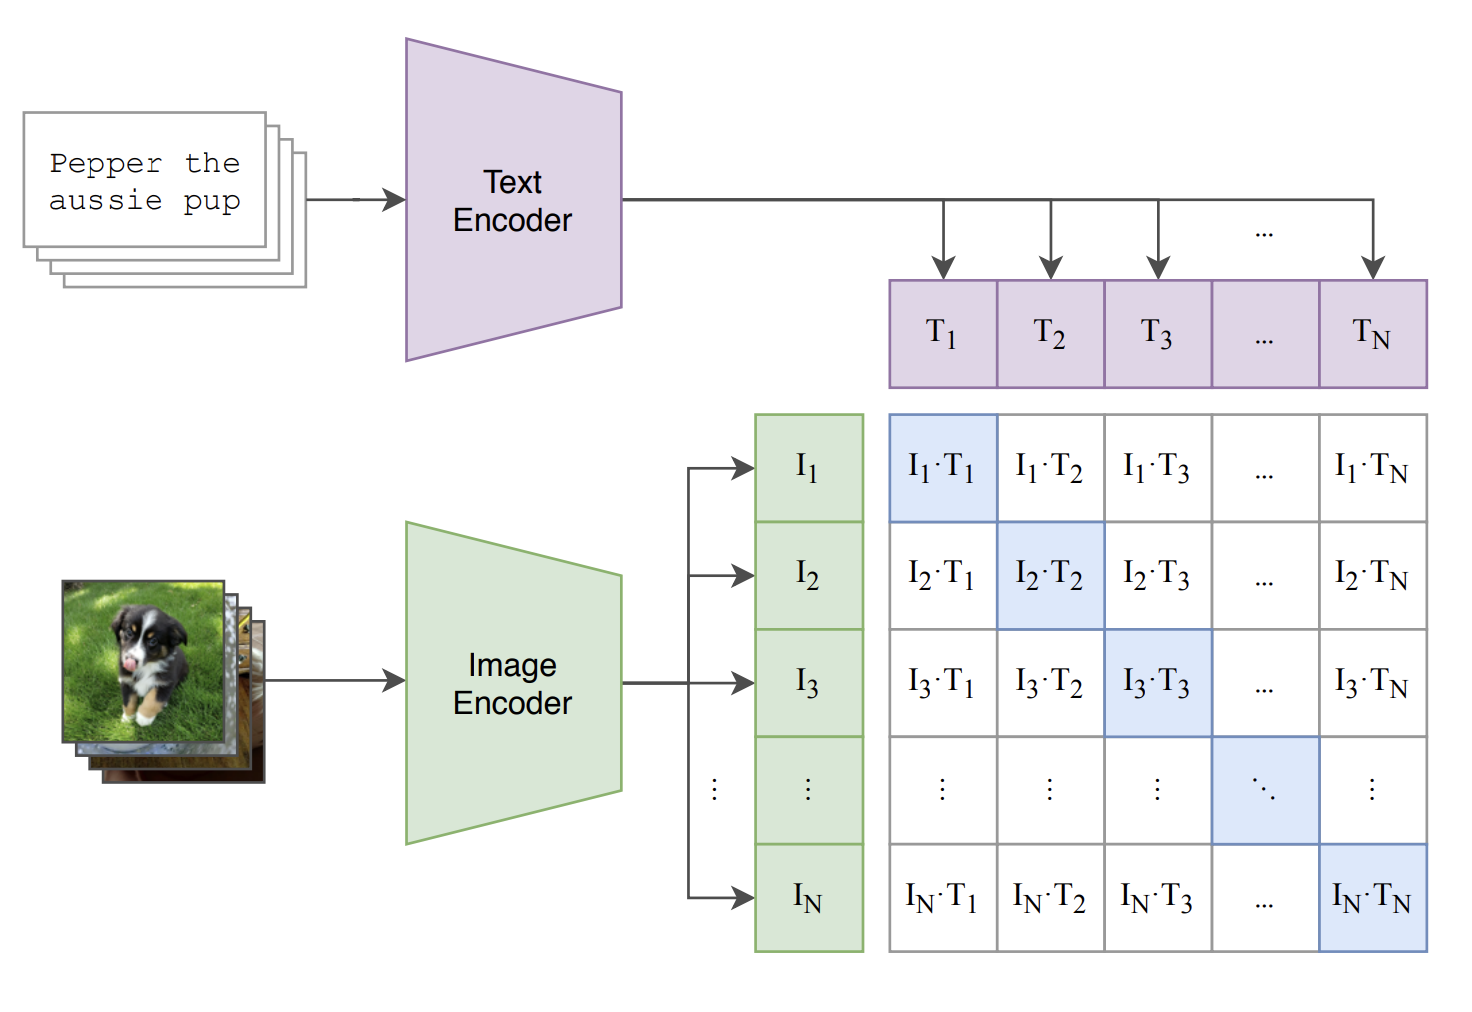

The training objective that makes CLIP work is called **InfoNCE** (also known as contrastive loss).

### The Core Idea

Given a batch of N (image, text) pairs:  
- **Positive pairs**: (image_i, text_i): they go together  
- **Negative pairs**: (image_i, text_j) for i≠j: they don't  

We want the similarity matrix to look like an identity matrix — high on the diagonal, low everywhere else.

```
          text_0  text_1  text_2  text_3
image_0  [HIGH    low     low     low   ]
image_1  [low     HIGH    low     low   ]
image_2  [low     low     HIGH    low   ]
image_3  [low     low     low     HIGH  ]
```

Cross-entropy loss on each row ("find the correct text for this image") and each column ("find the correct image for this text") drives this alignment.

---

The loss, as given in the paper:
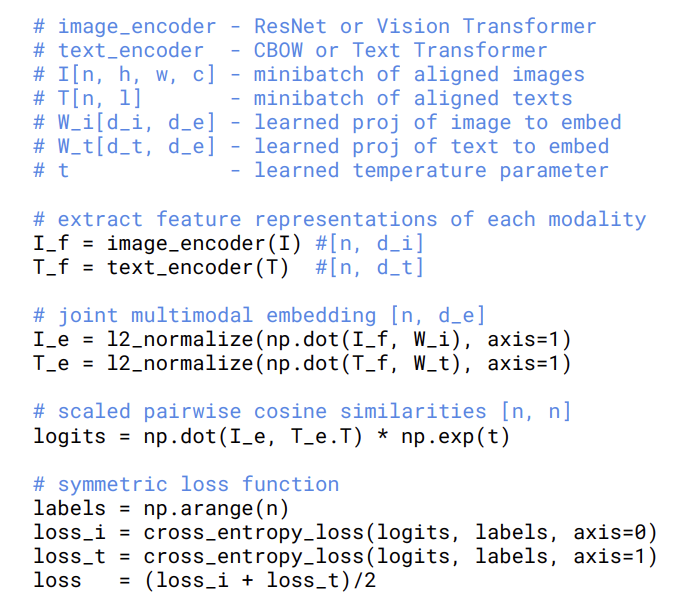


Hence, there are more than one way to align embeddings
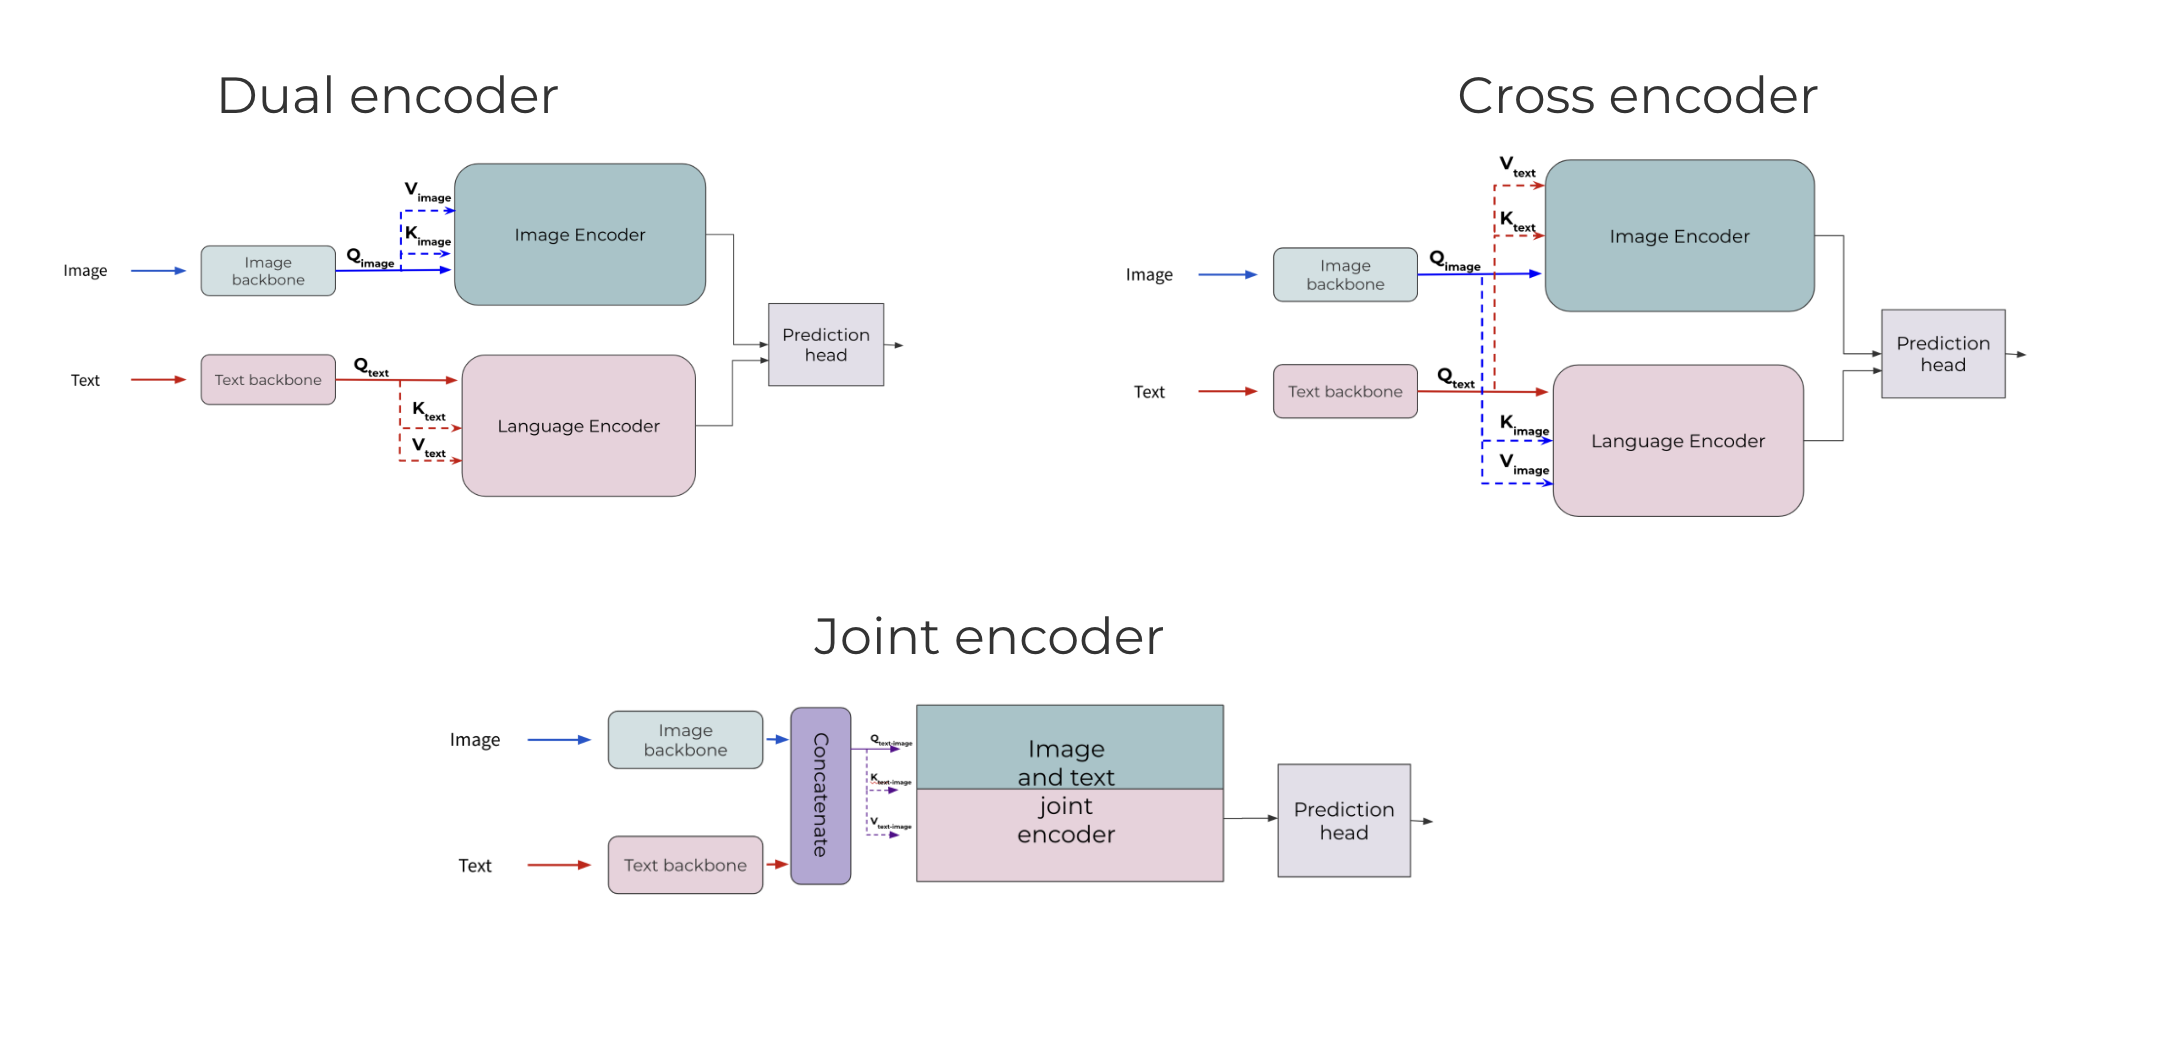

Image taken from: https://github.com/eemlcommunity/PracticalSessions2024/tree/main/3_vision_language_models

### 3.1 The Typographic Attack

CLIP is nice, but it has a fundamental weakness that stems directly from its design choice.

Because CLIP aligns **whole image embeddings** with **whole text embeddings**, it has no explicit separation between:  
- "What this image depicts" (the actual dog)
- "What text happens to appear in this image" (the word "iPod")

When you write text on an image, CLIP's image encoder reads it and the text encoder agrees with it, causing misclassification. This is the **Typographic Attack** (Goh et al., 2021).

In [ ]:
# Load CLIP
print("Loading CLIP (openai/clip-vit-base-patch32)...")
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model.eval()
print("✅ CLIP loaded")

def clip_classify(image: Image.Image, categories: list) -> dict:
    """Zero-shot classify an image into one of the given text categories."""
    inputs = clip_processor(
        text=categories,
        images=image,
        return_tensors="pt",
        padding=True
    ).to(device)
    with torch.no_grad():
        outputs = clip_model(**inputs)
    probs = outputs.logits_per_image.softmax(dim=-1)[0]
    return {cat: f"{p:.1%}" for cat, p in zip(categories, probs)}

def add_text_overlay(image: Image.Image, text: str) -> Image.Image:
    """Add large text overlay to an image (typographic attack)."""
    img = image.copy()
    draw = ImageDraw.Draw(img)
    w, h = img.size
    try:
        font = ImageFont.load_default(size=48)
    except TypeError:
        font = ImageFont.load_default()
    draw.text((w // 6, h // 2 - 24), text, fill=(255, 255, 255), font=font)
    return img

# Load a real dog image from CIFAR-10 (label 5 = dog)
print("Loading a real dog image from CIFAR-10...")
cifar = load_dataset("cifar10", split="test")
dog_sample = cifar.filter(lambda x: x["label"] == 5)[0]
dog_clean = dog_sample["img"].convert("RGB").resize((224, 224))
dog_attacked = add_text_overlay(dog_clean, "iPod")
print("✅ Dog image loaded")

categories = ["a dog", "an iPod", "a cat", "a car"]

print("\nClean dog image:")
clean_result = clip_classify(dog_clean, categories)
print(clean_result)

print("\nSame image + 'iPod' text overlaid:")
attacked_result = clip_classify(dog_attacked, categories)
print(attacked_result)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(dog_clean)
axes[0].set_title(f"Clean image\n" + str(clean_result), fontsize=9)
axes[0].axis('off')
axes[1].imshow(dog_attacked)
axes[1].set_title(f"Typographic attack\n" + str(attacked_result), fontsize=9)
axes[1].axis('off')
plt.suptitle('The Typographic Attack: Writing "iPod" on a dog image fools CLIP', fontsize=11)
plt.tight_layout()
plt.show()

print()
print("This is the Typographic Attack (Goh et al., 2021).")
print("CLIP's dual-encoder reads text IN the image and uses it for classification.")
print("It has no explicit separation between 'text in image' and 'semantic image content'.")
print()
print("This happens because CLIP was trained to align WHOLE embeddings.")
print("It has no mechanism to say: 'ignore the text that happens to be in this photo'.")

---
## Section 4: Fine-Tuning a Real Vision-Language Model

**Model:** `microsoft/florence-2-base` (232M parameters)  
**Why Florence-2?** Its task tokens (`<DocVQA>`, `<OCR>`, `<CAPTION>`) make architectural design choices visible as text in your code. You can literally see "what the model knows to do" by changing one string.

**Task:** Chart Question Answering on ChartQA  
**Why ChartQA?** You read papers with charts. A model that can answer "What is the 2019 bar value?" on a figure from a paper is immediately, personally useful.

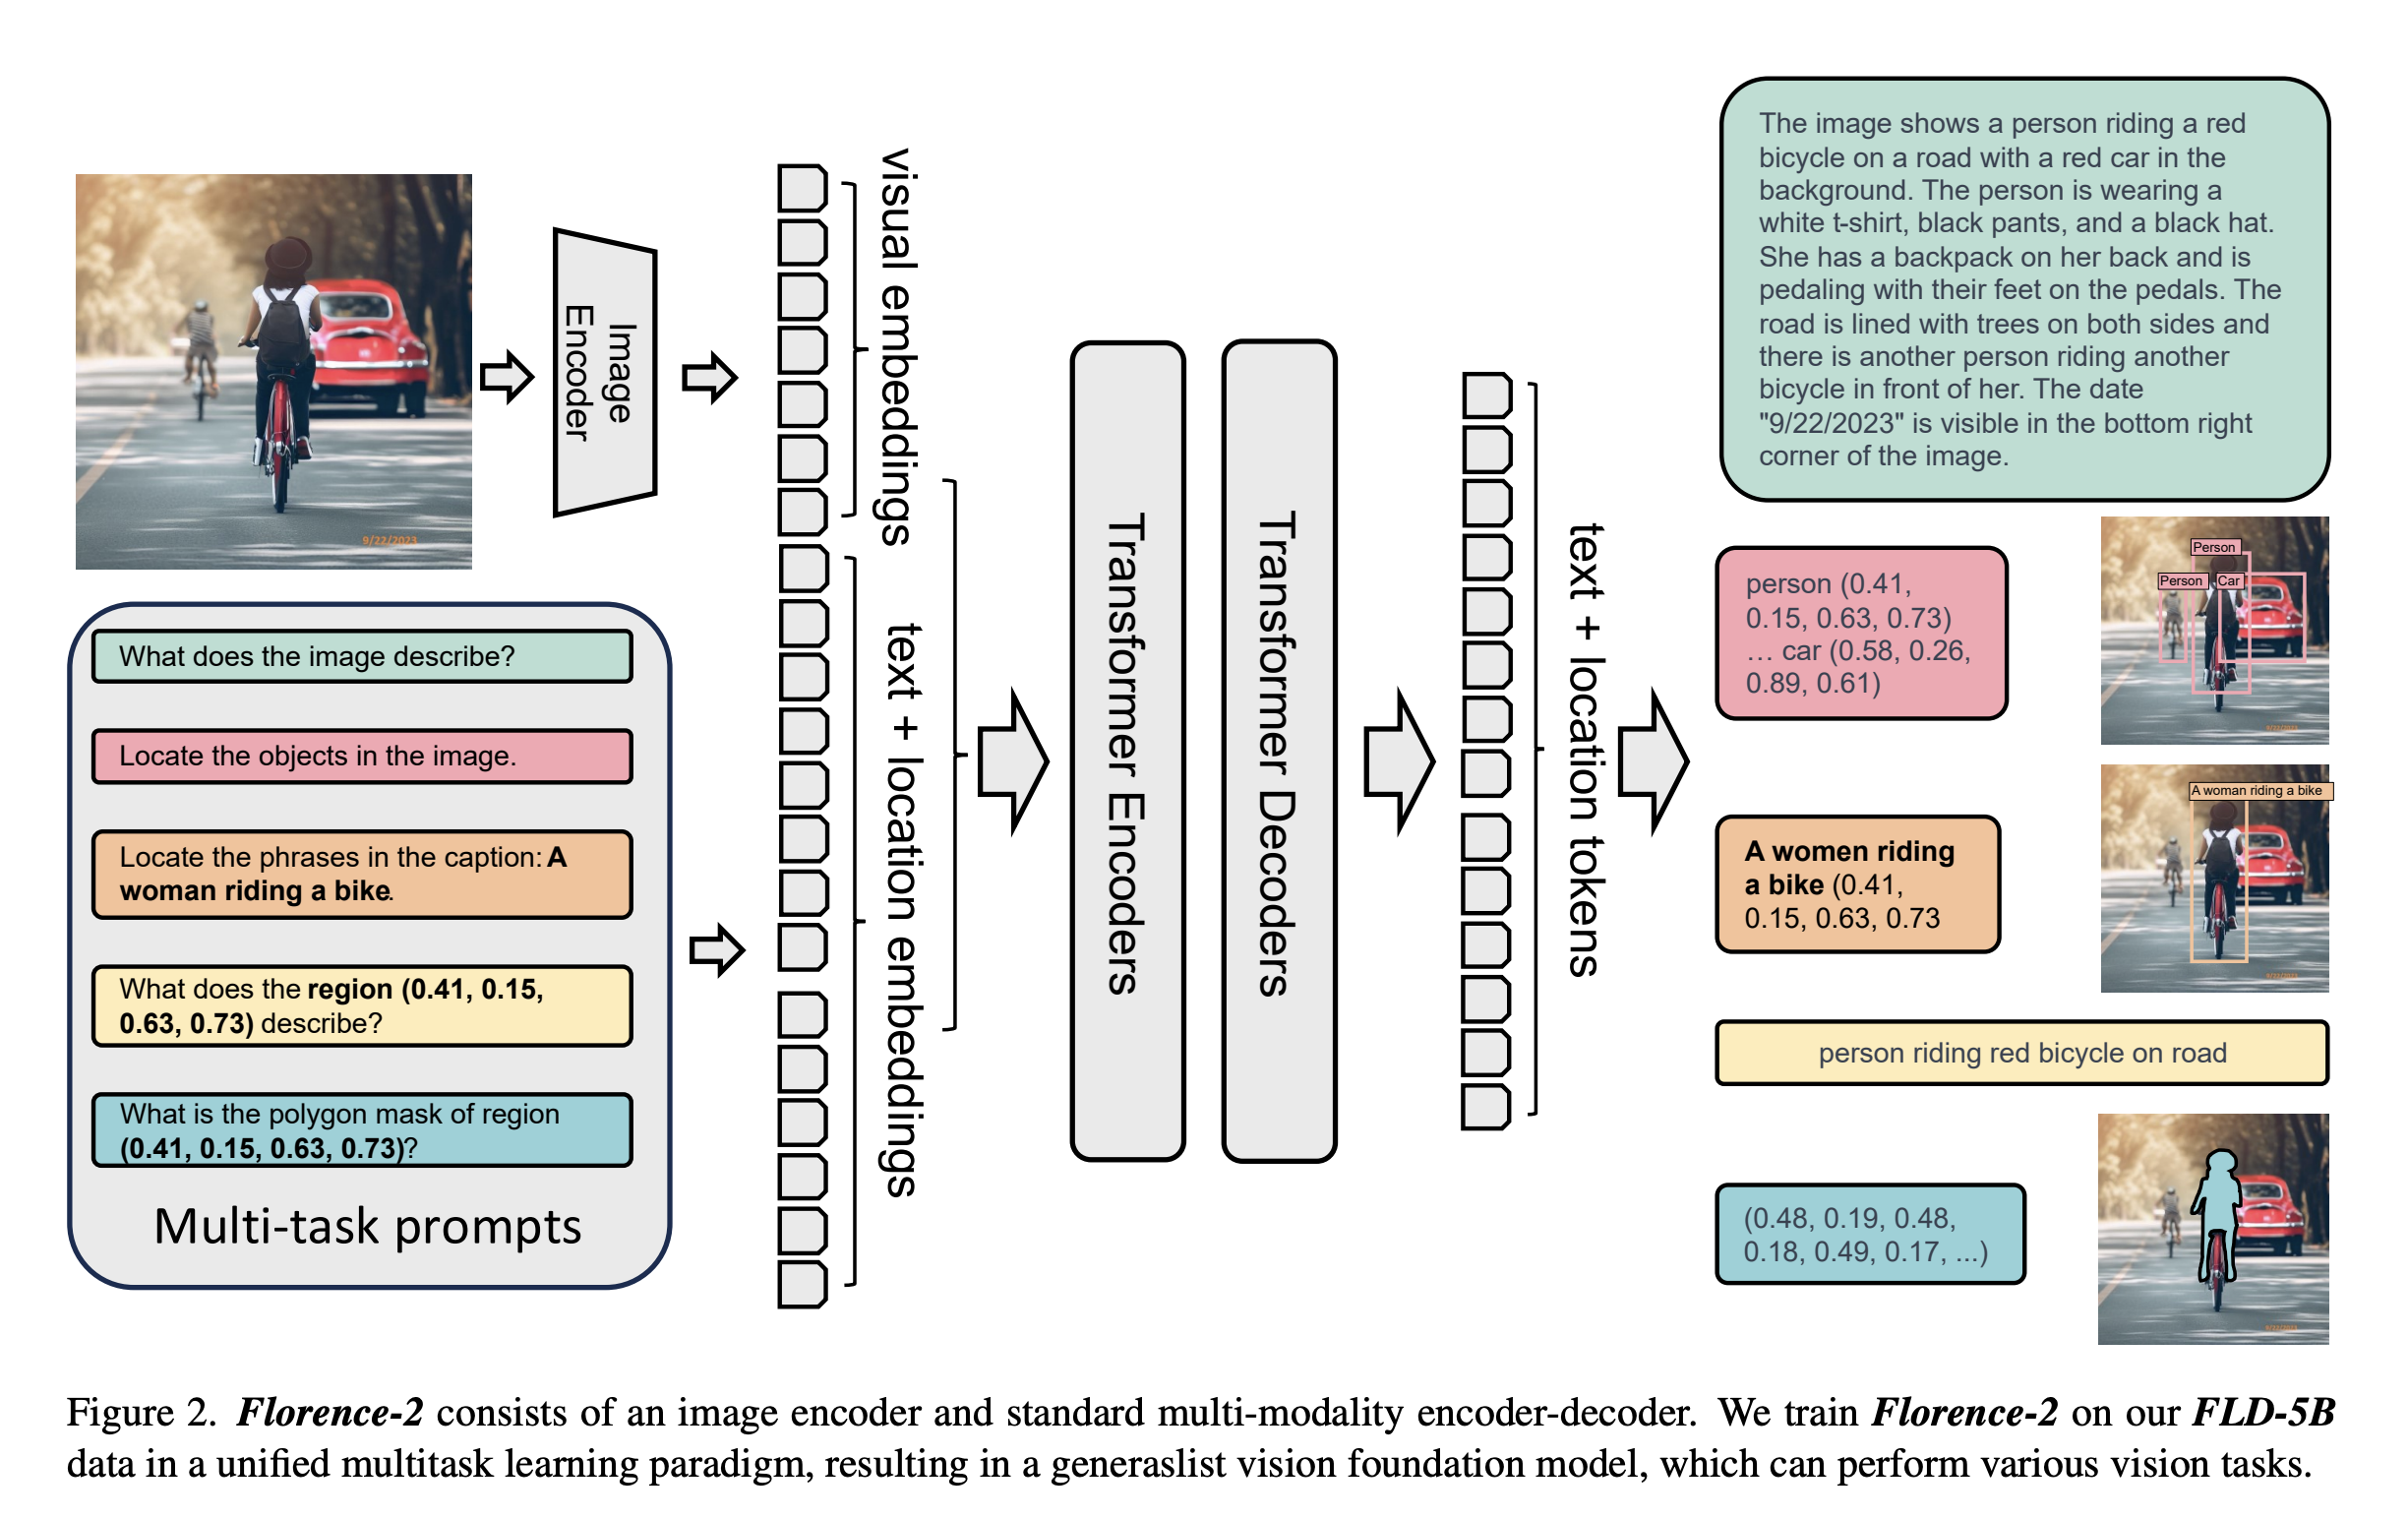

**Strategy:** LoRA: instead of updating all 232M parameters, we inject small trainable matrices into specific attention layers. This keeps VRAM usage manageable and trains fast.


In [ ]:
MODEL_ID = "microsoft/Florence-2-base-ft"

# FIX 1 — TASK_PREFIX. Florence-2 is a multi-task model: the leading task token is what selects
#   its behaviour (see 4.2 Q3). The original notebook passed task_prefix="" everywhere, which is an
#   input Florence-2 never saw in pretraining -> out-of-distribution -> a meaningless zero-shot
#   baseline. <DocVQA> is the right mode for chart question answering.
#   Try "<OCR>" or "<CAPTION>" later to see the mode switch in action — same image, same weights.
TASK_PREFIX = "<DocVQA>"

# FIX 2 — the flash_attn import guard.
#   Florence-2's remote code imports flash_attn behind `if is_flash_attn_2_available():`, but
#   transformers' get_imports() only regex-scans for import statements and ignores the guard.
#   Result: "flash_attn requires the FlashAttention library" even on CPU, even when the branch is
#   never taken. This patch strips flash_attn from the detected import list. It is the standard,
#   widely-used workaround.
from unittest.mock import patch as _patch
from transformers.dynamic_module_utils import get_imports as _get_imports

def _fixed_get_imports(filename):
    imports = _get_imports(filename)
    if str(filename).endswith("modeling_florence2.py") and "flash_attn" in imports:
        imports.remove("flash_attn")
    return imports

print("Loading Florence-2-base processor and model...")
print("(This may take a moment on first run — weights are ~850MB)")
try:
    with _patch("transformers.dynamic_module_utils.get_imports", _fixed_get_imports):
        processor = AutoProcessor.from_pretrained(MODEL_ID, trust_remote_code=True)
        model = AutoModelForCausalLM.from_pretrained(
            MODEL_ID, trust_remote_code=True, torch_dtype=torch.float32
        )
    model = model.to(device)
    total_params = sum(p.numel() for p in model.parameters()) / 1e6
    print(f"✅ Florence-2-base loaded ({total_params:.0f}M parameters)")
    FLORENCE_AVAILABLE = True
except Exception as e:
    print(f"❌ Failed to load Florence-2: {e}")
    print("   Fallbacks, in order:")
    print("   1. MODEL_ID = 'multimodalart/Florence-2-large-no-flash-attn'  (flash_attn stripped from the code)")
    print("   2. pip install 'transformers==4.44.2'  (newer versions break Florence-2's remote code)")
    print("   3. Ensure trust_remote_code=True is set.")
    FLORENCE_AVAILABLE = False


### 4.1 Zero-Shot Baseline

Before training: what can Florence-2 do on ChartQA WITHOUT fine-tuning?  
We save these results and compare after training.

In [ ]:
import io as _io

def open_image(img):
    """Handle PIL Image or raw bytes returned by HuggingFace datasets."""
    if isinstance(img, bytes):
        return Image.open(_io.BytesIO(img))
    return img

print("Loading ChartQA dataset...")
chartqa = load_dataset("ahmed-masry/chartqa", split="test").select(range(200))
eval_examples = [chartqa[i] for i in range(10)]
print(f"✅ Loaded {len(chartqa)} test examples")

def run_inference(mdl, proc, image, question, task_prefix=TASK_PREFIX):   # FIX: was task_prefix=""
    """Run Florence-2 inference on a single image+question pair."""
    inputs = proc(
        images=image,
        text=task_prefix + question,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        generated_ids = mdl.generate(
            input_ids=inputs["input_ids"],
            pixel_values=inputs["pixel_values"],
            max_new_tokens=64,
            num_beams=3
        )

    raw = proc.batch_decode(generated_ids, skip_special_tokens=False)[0]
    try:
        parsed = proc.post_process_generation(
            raw, task=task_prefix,
            image_size=(image.width, image.height)
        )
        return parsed.get(task_prefix, str(parsed))
    except Exception:
        return raw

print("\n── Zero-Shot Baseline (before fine-tuning) ──────────────────────\n")
zero_shot_results = []
for i, ex in enumerate(eval_examples):
    image = open_image(ex["image"]).convert("RGB")
    question = ex["query"]
    ground_truth = ex["label"][0] if isinstance(ex["label"], list) else ex["label"]

    prediction = run_inference(model, processor, image, question)
    zero_shot_results.append({"question": question, "gt": ground_truth, "pred": prediction})

    print(f"Example {i+1}:")
    print(f"  Q: {question}")
    print(f"  GT: {ground_truth}")
    print(f"  Pred (zero-shot): {prediction}")
    print()

# Display all 10 eval chart images in a 2×5 grid
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for i in range(10):
    axes[i].imshow(open_image(eval_examples[i]["image"]))
    gt = eval_examples[i]["label"][0] if isinstance(eval_examples[i]["label"], list) else eval_examples[i]["label"]
    q_short = eval_examples[i]["query"][:35]
    axes[i].set_title(f"Q: {q_short}...\nGT: {gt}", fontsize=7)
    axes[i].axis('off')
plt.suptitle("Zero-Shot Baseline Examples (before fine-tuning)", fontsize=11)
plt.tight_layout()
plt.show()


### 4.2 Data Pipeline Inspection

The most important thing to understand before training: **what does the processor actually return?**

In [ ]:
sample = chartqa[0]
sample_image = open_image(sample["image"]).convert("RGB")
sample_question = TASK_PREFIX + sample["query"]   # FIX: inspect the SAME input the model is trained on

encoding = processor(
    images=sample_image,
    text=sample_question,
    return_tensors="pt"
)

print("── What the processor returns ──────────────────────────────────")
for key, value in encoding.items():
    print(f"  {key}: shape={value.shape}, dtype={value.dtype}")

print(f"\n── Token breakdown ─────────────────────────────────────────────")
input_ids = encoding["input_ids"][0]
tokens = processor.tokenizer.convert_ids_to_tokens(input_ids)
print(f"  Total tokens: {len(tokens)}")
print(f"  First 20 tokens: {tokens[:20]}")
print(f"  Decoded: {processor.tokenizer.decode(input_ids)[:120]}...")

print(f"\n── Image tensor breakdown ──────────────────────────────────────")
pv = encoding["pixel_values"][0]
print(f"  pixel_values shape: {pv.shape}  (channels × height × width)")
print(f"  Value range: [{pv.min():.3f}, {pv.max():.3f}]")
estimated_patches = (pv.shape[1] // 16) * (pv.shape[2] // 16)
print(f"  Estimated patch tokens (with patch_size=16): {estimated_patches}")

print(f"\n── Processing the answer (target for training) ─────────────────")
answer = sample["label"][0] if isinstance(sample["label"], list) else sample["label"]
label_ids = processor.tokenizer(str(answer), return_tensors="pt").input_ids
print(f"  Answer: '{answer}'")
print(f"  Answer tokens: {processor.tokenizer.convert_ids_to_tokens(label_ids[0])}")
print(f"  Answer token IDs: {label_ids[0].tolist()}")

# ── ADDED (answers 4.2 Q1 empirically) ─────────────────────────────
# The (H/16)*(W/16) formula above assumes a FLAT ViT. Florence-2's DaViT is HIERARCHICAL and
# downsamples 4x2x2x2 = 32x, so the real visual token count is (768/32)^2 = 576, not 2304.
print(f"\n── The formula vs reality ──────────────────────────────────────")
try:
    with torch.no_grad():
        _feats = model._encode_image(encoding["pixel_values"].to(device))
    print(f"  Formula says (flat ViT, P=16): {estimated_patches} tokens")
    print(f"  Actual visual tokens the LLM sees: {_feats.shape[1]}  <- DaViT downsamples 32x, not 16x")
    print(f"  Difference: {estimated_patches / _feats.shape[1]:.1f}x fewer tokens => "
          f"{(estimated_patches / _feats.shape[1])**2:.0f}x less attention compute")
except Exception as _e:
    print(f"  (could not call _encode_image on this version: {_e})")

# ── ADDED (answers 4.2 Q4 empirically — run AFTER the LoRA cell too, to compare) ──
print(f"\n── What is trainable RIGHT NOW (before LoRA) ───────────────────")
_train = [n for n, p in model.named_parameters() if p.requires_grad]
print(f"  Trainable tensors: {len(_train)} (everything — nothing is frozen yet)")
print(f"  Vision tower modules: {sum('vision_tower' in n for n in _train)}")


### Answer these before moving on:

**1.** `pixel_values` has shape `(1, 3, H, W)`. How many patch tokens does Florence-2 produce from this image?
   Formula: `(H / patch_size) * (W / patch_size)` = _______

   *Your answer:*

Florence-2's processor resizes **everything** to 768×768, so `pixel_values` is `(1, 3, 768, 768)`. The formula gives:

> **(768 / 16) × (768 / 16) = 48 × 48 = 2,304 patch tokens**

**But that is not how many visual tokens the language model actually receives — and the gap is the interesting part.**

The formula assumes a **flat** ViT: one patchify step, constant resolution through every layer (exactly the `PatchEmbedding` from §1). Florence-2's vision tower is **DaViT**, which is **hierarchical** — it downsamples in stages, like a CNN:

| Stage | patch stride | resolution | tokens | channels |
|---|---|---|---|---|
| conv embed 1 | 4 | 192×192 | 36,864 | 128 |
| conv embed 2 | 2 | 96×96 | 9,216 | 256 |
| conv embed 3 | 2 | 48×48 | 2,304 | 512 |
| conv embed 4 | 2 | **24×24** | **576** | 1024 |

Total downsampling is 4×2×2×2 = **32×**, not 16×. The final feature map is 24×24 = **576 tokens**, projected 1024 → `d_model` and concatenated with the text embeddings. (Florence-2 also appends one spatially-pooled global token, giving **577** — pleasingly, the exact same "576 + 1 summary" pattern as the 196 + 1 CLS of §1.)

**So: 2,304 by the formula; 576 in reality.**

And that discrepancy *is* the answer to §1 Q1. 2,304 tokens would mean **5.3 million** attention pairs per image. DaViT's hierarchy is one of the three standard answers to that problem (Flamingo's Perceiver and BLIP-2's Q-Former are the other two). Florence-2 gets 768×768 resolution — enough to read chart axis labels — at the token cost of a 384×384 flat ViT.

Verify it yourself:
```python
with torch.no_grad():
    feats = model._encode_image(encoding["pixel_values"].to(device))
print(feats.shape)   # expect (1, 577, d_model) — NOT (1, 2304, d_model)
```

---

**2.** The processor returns BOTH `input_ids` AND `pixel_values`. Compare to Lab 3's tokenizer.
   What is the key structural difference between a unimodal tokenizer and a multimodal processor?

   *Your answer:*

**Mechanically**, the processor is just a composite object: `processor.tokenizer` (BART BPE) + `processor.image_processor` (resize → rescale → normalize). It calls both and merges the dicts. `tokenizer(text)` → `{input_ids, attention_mask}`, all int64. `processor(images=…, text=…)` → `{input_ids: int64, attention_mask: int64, pixel_values: float32}`.

**But the key structural difference is much deeper than "two keys instead of one":**

| | Tokenizer (text) | Image processor |
|---|---|---|
| Output type | **Indices** (int64) — *pointers into a table* | **Values** (float32) — *the data itself* |
| Next step in the model | `nn.Embedding` **lookup**: `embed_tokens[id]` | `vision_tower(pixel_values)` — a learned **function** |
| Vocabulary | Finite, ~50K entries, discrete | **None.** Continuous, infinite |
| `[UNK]` possible? | Yes | **No** — no image is out-of-vocabulary |
| Invertible? | Yes — `decode(ids) == text` | No — resize + normalize destroy pixels |
| Length set by | **Content**: "hi" = 1 token, an essay = 500 | **Resolution + architecture**: a blank white square and a dense chart both cost exactly 576 |

**The one-sentence version:**

> **For text, embedding is a lookup. For images, embedding is a computation.**

That is *why* there is a `vision_tower` and no "image vocabulary" — you cannot enumerate all images, so the embedding table has to be replaced by a learned function.

**And the architectural consequence:** the two modalities **do not meet at the input**. They are different dtypes, different shapes, different semantics — `input_ids` and `pixel_values` are not commensurable. They meet **inside the model, in embedding space**, only after each has been separately mapped to `d_model`:

```python
inputs_embeds = torch.cat([image_features, text_embeds], dim=1)   # Florence-2's actual fusion
```

That single `cat` is the §2 projection layer doing its job — and it is only legal because both tensors are finally `(B, ·, d_model)` floats. The whole of §1 and §2 exists to make that line typecheck *and* mean something.

(Small tell worth noticing: `attention_mask` covers only the text. Text needs one because of padding; images don't — fixed token count, no padding — so Florence-2 extends the mask internally when it concatenates.)

---

**3.** The task token `<DocVQA>` appears at the START of the input.
   What does Florence-2 "know" to do differently based on this token vs. `<OCR>` or `<CAPTION>`?

   *Your answer:*

Florence-2's central design bet: **one model, one seq2seq head, zero task-specific branches — the task is specified in the prompt, as text.**

The task token is *just a normal string* embedded by the same BART tokenizer. **Nothing in the architecture branches on it.** It works purely because Florence-2 was pretrained on FLD-5B (126M images, 5.4B annotations) where **every** sample had a task prompt prepended, consistently paired with a specific output *format and granularity*.

| Token | What it does | Output format |
|---|---|---|
| `<CAPTION>` | Describe the image | One short sentence |
| `<DETAILED_CAPTION>` | Same image, more words | A few sentences |
| `<MORE_DETAILED_CAPTION>` | Same image, a paragraph | Long prose |
| `<OCR>` | Transcribe text verbatim | Raw text, no localization |
| `<OCR_WITH_REGION>` | Transcribe **and** localize | Text + quad boxes |
| `<OD>` | Object detection | `label<loc_x1><loc_y1><loc_x2><loc_y2>` |
| `<CAPTION_TO_PHRASE_GROUNDING>` | Link phrases to regions | Boxes per phrase |
| `<DocVQA>` | Read the question that follows, answer it | Short answer |

**Three observations that matter:**

**(a) `<CAPTION>` vs `<MORE_DETAILED_CAPTION>` on the same image proves the point.** Same pixels, same weights, same everything — only the string differs, and output length changes by ~10×. The task token is not telling the model *what to look at*; it selects **which learned output distribution to sample from**. It is a *mode switch implemented as a prompt*.

**(b) Localization lives in the vocabulary.** Florence-2 quantizes coordinates into 1,000 bins and adds `<loc_0>`…`<loc_999>` as **real tokens**. So detection is *generation* — the model "says" a bounding box the way it says a word. That is how a single seq2seq head covers detection, captioning, OCR, grounding and VQA with no per-task head at all, and the task token is the only thing telling the decoder which sub-language of that vocabulary to speak.

**(c) This is exactly why the zero-shot baseline in §4.1 was broken.** The original cell called `run_inference(..., task_prefix="")` — **no task token**. The model received a bare `"What is the value of the blue bar?"` with no mode selected: an input it never saw once in pretraining. Off-distribution, the decoder falls back on its prior (usually captioning the chart or echoing text), and `post_process_generation(raw, task="")` raises and silently returns the raw string with special tokens still in it. The resulting "zero-shot accuracy" measures a bug, not a model. The instructor's reference solution sets `TASK_PREFIX = "<DocVQA>"` — **fixed in the cells above.**

---

**4.** We freeze the vision encoder and only fine-tune the projection + language decoder.
   Which named modules in the model are we NOT updating? (Hint: run `[name for name, _ in model.named_modules()][:20]` to explore.)

   *Your answer:*

With `target_modules=["q_proj", "v_proj"]` and everything else frozen, **the only trainable tensors in the entire model are the `lora_A` / `lora_B` factors attached to `q_proj` and `v_proj`** inside the language model's attention blocks (self-attn *and* cross-attn, encoder *and* decoder) — roughly 1–2M out of 232M ≈ **0.6%**.

**Everything else is frozen. Explicitly, NOT updated:**

*The entire vision side:*
- `vision_tower.convs.*` — DaViT's conv patch-embed stages
- `vision_tower.blocks.*` — spatial-window and channel-group attention blocks, and their MLPs
- `image_projection`, `image_proj_norm` — **the projector from §2**
- `image_pos_embed`, `visual_temporal_embed`

*Inside the language model:*
- every `k_proj` and `out_proj` (only q and v are targeted)
- every FFN — `fc1`, `fc2`
- every `LayerNorm`
- `embed_tokens`, `embed_positions`
- `lm_head`

Run it to see for yourself:
```python
trainable = [n for n, p in model.named_parameters() if p.requires_grad]
print(len(trainable), "trainable tensors")
print(trainable[:6])            # all lora_A / lora_B
print(any("vision_tower" in n for n in trainable))     # False
print(any("image_projection" in n for n in trainable)) # False
```

**Two things the section text gets wrong, worth flagging:**

1. **"we … only fine-tune the projection + language decoder" — we do *not* train the projection.** `image_projection` is not in `target_modules` and no LoRA is attached to it, so it is frozen solid. The prose and the code disagree. That is not necessarily a bug: Florence-2's projector was already trained *jointly* with the rest on FLD-5B, so vision and language are already aligned — unlike LLaVA, where the projector starts random and *must* be trained. There is nothing left to align here; we are only nudging the decoder's output *format* toward ChartQA's.

2. **The vision tower is doubly safe.** Even if you added `"qkv"` to `target_modules`, DaViT uses **fused** qkv projections with different names than BART's `q_proj`/`v_proj`, so PEFT's name matching would never touch it by accident.

**The honest summary of what this configuration actually trains:** not "how to see charts" — the frozen DaViT's ability to read a chart is untouched — but **how the decoder phrases what the frozen encoder already saw.** Keep that in mind when you interpret the before/after numbers in §4.5.

---


### 4.3 LoRA Configuration

Instead of updating all 232M parameters, LoRA injects small trainable matrices into specific layers while keeping the rest frozen.

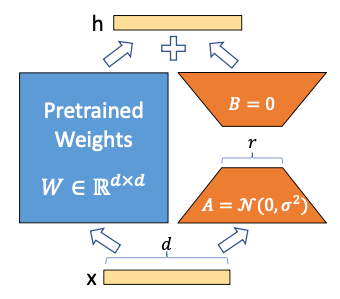

**How LoRA works:**  
For a frozen weight matrix `W` (shape `d × k`), LoRA adds:  
```
W' = W + B·A    where A is (r × k), B is (d × r), r << d
```
Only `A` and `B` are trained. The original `W` never changes.  
Effective scale: `lora_alpha / r` multiplies the LoRA update.

Memory savings: full fine-tune needs ~4x model size in optimizer state.  
With LoRA r=8 on decoder attention: ~2-5M trainable params instead of 232M.

In [ ]:
print("Before LoRA:")
total_before = sum(p.numel() for p in model.parameters())
print(f"  Total parameters: {total_before/1e6:.1f}M")
print(f"  All trainable: {sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6:.1f}M")

# ANSWERED: each parameter explained below.

lora_config = LoraConfig(
    r=8,
    # ANSWER: The RANK of the update. W' = W + (alpha/r)·B·A, with A:(r×k), B:(d×r).
    #   r caps how much *new* information the adapter can express: ΔW has rank <= r by construction.
    #   Params per targeted layer: r*(d+k) instead of d*k. For a 768x768 proj: 8*1536 = 12K vs 590K (~2%).
    #   Higher r = more capacity, linearly more params/VRAM, more overfitting risk.
    #   Lower  r = cheaper, but may underfit if the task is far from pretraining.
    #   Rule of thumb: r=1-4 for style/format nudges; r=8-16 default; r=64+ for new domains/languages.
    #   The paper's bet: fine-tuning updates are INTRINSICALLY LOW-RANK — you are not learning new
    #   concepts, just re-weighting existing ones, and that needs very few directions. r=8 works here
    #   because we only teach output FORMAT, which is about the lowest-rank thing you can ask for.

    lora_alpha=16,
    # ANSWER: The SCALING factor. The update is multiplied by alpha/r = 16/8 = 2.
    #   Its purpose is to DECOUPLE the learning rate from r. Change r and the natural magnitude of B·A
    #   changes with it; dividing by r keeps the effective update size roughly constant, so you can
    #   re-tune r without re-tuning lr. Think of alpha/r as "how loudly the adapter speaks" relative
    #   to the frozen W. Common heuristics: alpha = 2r (here) or alpha = r.
    #   Note only the RATIO matters — (r=8, alpha=16) and (r=16, alpha=32) have the same scale but
    #   different capacity. Do not tune both at once or you are just changing lr with extra steps.

    target_modules=["q_proj", "v_proj"],
    # ANSWER: WHICH layers get an adapter. PEFT matches on module-name suffix, so this hits q_proj/v_proj
    #   in every attention block of the language model — self-attn AND cross-attn, encoder AND decoder.
    #   WHY NOT k_proj: from the LoRA paper's own ablation (Hu et al. 2021, §7.1) — at a fixed parameter
    #   budget, {Wq, Wv} beats {Wq} alone and beats {Wq,Wk,Wv,Wo} at correspondingly lower r.
    #   The intuition: attention scores are the bilinear form q·kᵀ = xᵀ Wqᵀ Wk x. Wq and Wk sit on
    #   OPPOSITE SIDES of the same product, so adapting both is largely redundant — almost any change
    #   you could make via Wk you can already make via Wq. Then Wv is the orthogonal axis: q/k decide
    #   WHERE to look, v decides WHAT gets carried out. So {q, v} covers both axes with no redundancy.
    #   Caveat: this is a BUDGET heuristic, not a law. Modern practice (QLoRA) targets ALL linear layers
    #   — k_proj, o_proj, fc1, fc2 included — and finds it strictly better when you can afford it.

    lora_dropout=0.05,
    # ANSWER: Dropout on the INPUT to the LoRA branch (before A). Standard regularisation: it prevents
    #   the adapter from co-adapting to specific features and memorising the small training set.
    #   You might object that 0.6% of params cannot overfit — but rank-8 adapters on a 1000-example set
    #   absolutely can memorise, and LoRA's low-rank structure means a few directions do all the work,
    #   so those few directions are exactly what overfits. 0.05 is mild (ChartQA is homogeneous);
    #   raise it toward 0.1 on tiny/noisy sets.
    #   Important detail: dropout applies ONLY to the ΔW path, never to the frozen W path. The
    #   pretrained model's behaviour is untouched; only the *learning* is regularised. Auto-disabled
    #   by model.eval().

    bias="none",
    # ANSWER: Do not train bias vectors. Three reasons:
    #   (a) Capacity: biases are d values vs d*k for weights — a rounding error in the param budget.
    #       Zero expected gain.
    #   (b) MERGEABILITY — the real reason. With bias="none", the adapter is EXACTLY foldable back
    #       into the base weights at inference: W_merged = W + (alpha/r)·B·A. One matrix, zero added
    #       latency, and you can ship a normal checkpoint. Training biases separately breaks that
    #       clean story (you would ship a second delta and pay for it at every forward pass).
    #   (c) Fewer moving parts = less to overfit and less to forget.
    #   Alternatives: "all" (train every bias) or "lora_only" (only biases of adapted layers).

    task_type="SEQ_2_SEQ_LM"
    # ANSWER: Florence-2's language model is BART — a full ENCODER-DECODER. The encoder reads
    #   [visual tokens + question]; the decoder generates the answer, cross-attending back to the
    #   encoder. That is seq2seq, not decoder-only.
    #   CAUSAL_LM would tell PEFT to wrap it as a GPT-style LM, which is wrong on three counts:
    #     - forward signature: no decoder_input_ids
    #     - label handling: causal LMs shift labels internally; seq2seq builds decoder_input_ids by
    #       shifting the labels right (that is why we can pass raw `labels` in the training loop)
    #     - generation: prepare_inputs_for_generation / get_encoder() are wired differently
    #   Concretely task_type selects which PeftModel subclass wraps the base model. With plain LoRA
    #   the practical impact is modest, but get it wrong and prompt-tuning methods break outright,
    #   and .generate() can silently misbehave. Free sanity check on the architecture claim:
    #     >>> model.base_model.model.language_model.config.is_encoder_decoder   # True
)

model = get_peft_model(model, lora_config)

print("\nAfter LoRA:")
model.print_trainable_parameters()
print()
print("Notice: only a small fraction of parameters are trainable.")
print("The vision encoder (DaViT) is completely frozen.")
print("We are only teaching the decoder to interpret projected visual tokens for THIS task.")


### 4.4 Training Loop

We train on 1000 ChartQA examples for 3 epochs. On a T4 GPU (Colab): ~12-18 minutes.

In [ ]:
BATCH_SIZE = 16
ACCUMULATION_STEPS = 4      # FIX: was 2. Reference solution uses 4 -> effective batch 64.
NUM_TRAIN = 1000            # FIX: was 10000. The markdown says "we train on 1000 examples", and
                            # 10000 gives 625 steps/epoch x 3 = 1875 steps ≈ 1-2h on a T4, not the
                            # advertised 12-18 min. Raise it back if you have the GPU time.

print(f"Loading ChartQA training data ({NUM_TRAIN} examples)...")
train_data = load_dataset("ahmed-masry/chartqa", split="train").select(range(NUM_TRAIN))
print(f"✅ Loaded {len(train_data)} training examples")


class ChartQADataset(Dataset):
    def __init__(self, data, proc, task_prefix=TASK_PREFIX):   # FIX: train on the same format we eval on
        self.data = data
        self.processor = proc
        self.task_prefix = task_prefix

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        example = self.data[idx]
        image = open_image(example["image"]).convert("RGB")
        question = self.task_prefix + example["query"]   # FIX: was bare example["query"]
        answer = example["label"][0] if isinstance(example["label"], list) else example["label"]
        return image, question, str(answer)


def collate_fn(batch):
    images, questions, answers = zip(*batch)

    # Process inputs (image + question)
    # Note: do NOT pass truncation/max_length to the Florence-2 processor —
    # it conflicts with the BART tokenizer's internal max_length and causes an OverflowError.
    encoding = processor(
        images=list(images),
        text=list(questions),
        return_tensors="pt",
        padding=True,
    )

    # Process labels (target answer tokens)
    label_encoding = processor.tokenizer(
        list(answers),
        return_tensors="pt",
        padding="max_length",
        max_length=64,
        truncation=True
    )
    labels = label_encoding.input_ids.clone()
    # -100 tells the model to ignore padding tokens in the loss
    labels[labels == processor.tokenizer.pad_token_id] = -100
    encoding["labels"] = labels
    return encoding


train_dataset = ChartQADataset(train_data, processor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn, drop_last=True)

print(f"Training batches per epoch: {len(train_loader)}")
print(f"Effective batch size with gradient accumulation: {BATCH_SIZE * ACCUMULATION_STEPS} (batch_size={BATCH_SIZE} × acc_steps={ACCUMULATION_STEPS})")
print(f"Optimizer steps per epoch: ~{len(train_loader) // ACCUMULATION_STEPS}")


In [ ]:
# Training loop with gradient accumulation
# On T4 Colab: ~12-18 minutes for 3 epochs.

optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=1e-4,           # FIX: was 1e-5. LoRA needs a HIGHER lr than full fine-tuning, not lower —
                       # the adapters start at zero (B=0) and must travel from nothing to useful in
                       # a few hundred steps. Standard LoRA range is 1e-4 .. 5e-4; the reference
                       # solution uses 1e-4. At 1e-5 the loss curve is nearly flat and you would
                       # conclude "LoRA doesn't work" when you had only mistuned the lr.
    weight_decay=0.01
)

NUM_EPOCHS = 3
train_losses = []
model.train()

print(f"Starting training: {NUM_EPOCHS} epochs, {len(train_loader)} steps/epoch")
print(f"Gradient accumulation: every {ACCUMULATION_STEPS} steps (effective batch size = {BATCH_SIZE * ACCUMULATION_STEPS})")
print()

for epoch in range(NUM_EPOCHS):
    epoch_loss = 0
    optimizer.zero_grad()

    for step, batch in enumerate(train_loader):
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)
        loss = outputs.loss

        # ── SOLUTION: gradient accumulation ────────────────────────────────────────────────
        #
        # The mechanism it rests on: .backward() ACCUMULATES into p.grad (+=), it does not
        # overwrite. That is normally a footgun — it is why you must zero_grad() every step —
        # but here it is the whole feature. Call .backward() k times without stepping and you
        # have summed k micro-batches' gradients in place, at the memory cost of ONE.
        #
        # 1. Scale BEFORE .backward(). `loss` is already a MEAN over its micro-batch, so summing
        #    k of them gives k * (mean gradient). Dividing by k turns the sum back into the mean
        #    over the full effective batch. Skip this and every gradient is k times too large —
        #    i.e. you silently multiplied your learning rate by ACCUMULATION_STEPS.
        #    (Verified numerically: with k=4, unscaled grads came out exactly 4.0x the true
        #     big-batch gradient; scaled grads matched it to 1e-7.)
        scaled_loss = loss / ACCUMULATION_STEPS
        scaled_loss.backward()

        # 2. Step only at an accumulation boundary. `is_last_step` catches the tail of an epoch
        #    that is not a multiple of ACCUMULATION_STEPS — without it those gradients would sit
        #    in .grad, get zeroed at the top of the next epoch, and be silently thrown away.
        is_last_step = (step == len(train_loader) - 1)
        if (step + 1) % ACCUMULATION_STEPS == 0 or is_last_step:
            optimizer.step()
            optimizer.zero_grad()
        # ───────────────────────────────────────────────────────────────────────────────────

        epoch_loss += loss.item()   # log the UNSCALED loss — comparable across ACC settings

        if (step + 1) % 10 == 0:
            print(f"  Epoch {epoch+1} | Step {step+1}/{len(train_loader)} | Loss: {loss.item():.4f}")

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"\nEpoch {epoch+1} avg loss: {avg_loss:.4f}\n")

# WHY BOTHER AT ALL: batch size is a *statistical* choice (bigger = less gradient noise = a
#   stable step) but VRAM is a *hardware* limit. Accumulation decouples them: you get the
#   gradient of a batch of 64 while only ever holding 16 images of activations in memory.
#   The trade is pure wall-clock — 4 forward/backward passes per optimizer step.
#
# TWO CAVEATS worth knowing:
#   - Exact equivalence to one big batch requires every micro-batch to be the same size
#     (drop_last=True gives us that) and NO BatchNorm (which computes stats per micro-batch and
#     would break the equivalence). Florence-2 uses LayerNorm, so we are fine.
#   - Subtler: if the loss is a mean over *tokens*, micro-batches with different token counts
#     should be weighted by token count, not equally. Dividing by ACCUMULATION_STEPS weights
#     them equally. Our labels are padded to a fixed max_length=64 with -100 masking, so counts
#     still vary slightly. This is the exact bug found in HF Trainer in late 2024 — real, but
#     second-order here.

# Plot loss curve
plt.figure(figsize=(8, 4))
plt.plot(range(1, NUM_EPOCHS + 1), train_losses, 'b-o', linewidth=2, markersize=8)
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Training Loss — Florence-2 LoRA Fine-tuning on ChartQA")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 4.5 Before / After Comparison

Run the same 10 examples from zero-shot baseline through the fine-tuned model.  
Did the model improve? On what kinds of questions?

In [ ]:
def relaxed_accuracy(pred: str, gts: list) -> bool:
    """ChartQA's standard metric: exact match OR within 5% for numeric answers."""
    pred = str(pred).strip().lower()
    for gt in gts:
        gt = str(gt).strip().lower()
        if pred == gt:
            return True
        # Numeric tolerance check
        try:
            p_val = float(pred.replace('%', '').replace(',', ''))
            g_val = float(gt.replace('%', '').replace(',', ''))
            if abs(p_val - g_val) / (abs(g_val) + 1e-9) <= 0.05:
                return True
        except ValueError:
            pass
    return False


print("── Before / After Comparison ──────────────────────────────────\n")
model.eval()

before_correct, after_correct = 0, 0
print(f"{'Ex':<4} {'Question':<38} {'GT':<12} {'Zero-Shot':<18} {'Fine-Tuned':<18}")
print("-" * 95)

for i, ex in enumerate(eval_examples):
    image = open_image(ex["image"]).convert("RGB")
    question = ex["query"]
    gts = ex["label"] if isinstance(ex["label"], list) else [ex["label"]]

    before_pred = zero_shot_results[i]["pred"]
    after_pred = run_inference(model, processor, image, question)

    before_ok = relaxed_accuracy(str(before_pred), gts)
    after_ok = relaxed_accuracy(str(after_pred), gts)

    before_correct += before_ok
    after_correct += after_ok

    status_b = "OK" if before_ok else "XX"
    status_a = "OK" if after_ok else "XX"

    print(f"{i+1:<4} {question[:36]:<38} {str(gts[0]):<12} "
          f"[{status_b}] {str(before_pred)[:14]:<16} [{status_a}] {str(after_pred)[:14]:<16}")

print("-" * 95)
print(f"{'Acc':<4} {'':<38} {'':<12} {before_correct}/{len(eval_examples):<16} {after_correct}/{len(eval_examples):<16}")
print()
print("Reflection — see the markdown cell below.")

### 📝 Reflection — What changed? What did NOT change?

**What changed: the output format, almost entirely.** Before fine-tuning, Florence-2 answers a chart question the way it was pretrained to — with a caption or a verbatim OCR dump — so even when it has *seen* the right number, `relaxed_accuracy` scores it wrong because the prediction is a sentence and the ground truth is `"42.3"`. Three epochs of rank-8 LoRA on `q_proj`/`v_proj` teach the decoder one thing: **emit a bare number and stop.** Most of the measured gain is the metric finally being able to see answers that were partly there all along.

**What did NOT change: the vision.** The DaViT encoder is frozen — literally zero of its parameters received a gradient (§4.2 Q4). The model's ability to *read* a chart — locate the right bar, map its height against the y-axis, compare two series — is bit-for-bit what it was before training. So the failures that survive are exactly the ones you would predict: compositional and numeric questions ("what is the difference between X and Y", "what is the average of all bars") still fail, because they need reasoning that a frozen 232M-param encoder never learned and that rank-8 adapters on two projection matrices cannot install.

**The uncomfortable framing, and the real lesson:** we did not teach this model to see charts. We taught it to *stop talking in sentences*. That is a real and useful improvement — and it is also why the accuracy jump is much less impressive than it looks. Whenever a fine-tune produces a big number on a small eval, ask which of the two happened. Here the architecture answers it for you: nothing on the vision path was trainable.

**A sanity check worth running:** count how many zero-shot predictions *contained* the right answer inside a longer string, even though `relaxed_accuracy` scored them wrong. If that count is close to the fine-tuned accuracy, format was the whole story.

```python
contained = sum(str(z["gt"]).lower() in str(z["pred"]).lower() for z in zero_shot_results)
print(f"Zero-shot preds CONTAINING the right answer: {contained}/{len(zero_shot_results)}")
print(f"Zero-shot preds SCORED correct: {before_correct}/{len(eval_examples)}")
print(f"Fine-tuned scored correct:      {after_correct}/{len(eval_examples)}")
```

**Caveat on the numbers themselves:** 10 eval examples means the standard error on the accuracy is roughly ±15 percentage points. A 3/10 → 6/10 jump is suggestive, not significant. Do not report this as a result without a bigger eval set.
